## Kaggle Setup

Attach the ScanNet-style dataset used by the partner long run, usually `klein2111/scannet-2d`, and attach/copy the adapted checkpoint `best_100ep.pt`.

If the Depth Anything V2 metric checkpoint is not already present in the repo or Kaggle input, attach it as a Kaggle input or set `allow_internet_downloads=True`.

`SMOKE_TEST` mode validates metrics, masks, plotting, CSV writing, report writing, logging, and zip export on dummy tensors without requiring the real dataset/checkpoints.


In [3]:
from __future__ import annotations

import json
import logging
import math
import os
import random
import shutil
import subprocess
import sys
import time
import traceback
import zipfile
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    import cv2
except Exception as exc:
    raise RuntimeError("OpenCV is required to load ScanNet RGB/depth files.") from exc

try:
    import torch
    import torch.nn.functional as F
except Exception as exc:
    raise RuntimeError("PyTorch is required for EagleVision evaluation.") from exc

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("matplotlib is required for plots and qualitative grids.") from exc

try:
    from skimage.metrics import structural_similarity as skimage_ssim
except Exception:
    skimage_ssim = None

try:
    import lpips  # type: ignore
    LPIPS_AVAILABLE = True
except Exception:
    lpips = None
    LPIPS_AVAILABLE = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}; LPIPS available: {LPIPS_AVAILABLE}; skimage SSIM available: {skimage_ssim is not None}")


Device: cuda; LPIPS available: False; skimage SSIM available: True


## Configuration

Edit this cell for Kaggle paths or runtime mode. `QUICK_RUN=True` is the default so a fresh Kaggle kernel can verify the suite end-to-end before a full 780-pair run.


In [4]:
CONFIG: dict[str, Any] = {
    "seed": 7,
    "image_size": [192, 288],
    "eval_batch_size": 1,
    "quick_run": False,
    "full_run": True,
    "max_eval_pairs_quick": 50,
    "max_eval_pairs_full": 780,
    "max_qualitative_cases": 5,
    "smoke_test": False,
    "allow_internet_downloads": False,
    "repo_url": "https://github.com/alooboii/EagleVision.git",
    "download_baseline_checkpoint_if_missing": True,
    "depth_mode": "metric",
    "encoder": "vits",
    "profile": "hypersim",
    "adapter_hidden_channels": 32,
    "min_translation_m": 0.02,
    "max_translation_m": 0.30,
    "min_rotation_deg": 0.8,
    "max_rotation_deg": 8.0,
    "max_index_gap": 10,
    "frame_stride": 2,
    "max_frames_per_scene": 180,
    "max_pairs_per_scene": 120,
    "train_scene_fraction": 0.90,
    "min_valid_pixels": 128,
    "output_root": "outputs/eval_suite_phase1",
    "manual_dataset_root": "/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d",
    "manual_dav2_checkpoint": None,
    "manual_adapted_checkpoint": None,
    "default_intrinsics": [
        [577.8706, 0.0, 159.5],
        [0.0, 577.8706, 119.5],
        [0.0, 0.0, 1.0],
    ],
}

if CONFIG["full_run"]:
    CONFIG["quick_run"] = False
MAX_EVAL_PAIRS = int(CONFIG["max_eval_pairs_full"] if CONFIG["full_run"] else CONFIG["max_eval_pairs_quick"])
SMOKE_TEST = bool(CONFIG["smoke_test"])

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")
RUNNING_ON_KAGGLE = KAGGLE_WORKING.exists()


def looks_like_repo(path: Path) -> bool:
    return (path / "src" / "eaglevision").exists() and (path / "baseline" / "depth_anything_v2").exists()


def find_existing_repo() -> Path | None:
    candidates = [Path.cwd().resolve()]
    if RUNNING_ON_KAGGLE:
        candidates.extend([
            KAGGLE_WORKING / "EagleVision",
            KAGGLE_WORKING / "EagleVision" / "EagleVision",
            KAGGLE_WORKING / "EagleVision_repo",
        ])
    for candidate in candidates:
        if looks_like_repo(candidate):
            return candidate
    return None


def clone_repo_to_available_path() -> Path:
    if not RUNNING_ON_KAGGLE:
        raise RuntimeError("Repo clone fallback is only configured for Kaggle.")
    clone_targets = [KAGGLE_WORKING / "EagleVision", KAGGLE_WORKING / "EagleVision_repo"]
    last_error = ""
    for target in clone_targets:
        if target.exists() and any(target.iterdir()):
            if looks_like_repo(target):
                return target
            print(f"[setup] {target} exists but is not the repo root; trying another clone path")
            continue
        print(f"[setup] cloning EagleVision into {target}")
        result = subprocess.run(
            ["git", "clone", CONFIG["repo_url"], str(target)],
            cwd=KAGGLE_WORKING,
            text=True,
            capture_output=True,
        )
        if result.returncode == 0 and looks_like_repo(target):
            return target
        last_error = f"stdout:\n{result.stdout}\nstderr:\n{result.stderr}"
    raise RuntimeError(
        "Could not locate or clone EagleVision. Enable Kaggle internet, or attach/copy a repo folder containing "
        "src/eaglevision and baseline/depth_anything_v2.\n" + last_error
    )

REPO_DIR = find_existing_repo()
if REPO_DIR is None:
    REPO_DIR = clone_repo_to_available_path() if RUNNING_ON_KAGGLE else Path.cwd().resolve()

if not looks_like_repo(REPO_DIR):
    raise RuntimeError(
        f"EagleVision repo root is not available at {REPO_DIR}. "
        "Run this notebook from the repo root, clone the repo, or attach it on Kaggle."
    )

SRC_DIR = REPO_DIR / "src"
for path_entry in [SRC_DIR, REPO_DIR]:
    if str(path_entry) not in sys.path:
        sys.path.insert(0, str(path_entry))
os.environ["PYTHONPATH"] = f"{SRC_DIR}{os.pathsep}{REPO_DIR}{os.pathsep}{os.environ.get('PYTHONPATH', '')}"

OUTPUT_ROOT = REPO_DIR / CONFIG["output_root"]
for rel in [
    "logs", "dataset", "pairs", "metrics", "plots", "diagnostics",
    "qualitative/random_cases", "qualitative/best_cases", "qualitative/worst_cases",
    "qualitative/adapted_best_improvements", "qualitative/adapted_worst_regressions",
    "qualitative/easy_cases", "qualitative/medium_cases", "qualitative/hard_cases",
    "debug_sanity",
]:
    (OUTPUT_ROOT / rel).mkdir(parents=True, exist_ok=True)

LOG_PATH = OUTPUT_ROOT / "logs" / "eval_suite.log"
PAIR_ERRORS_PATH = OUTPUT_ROOT / "logs" / "pair_errors.jsonl"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8"), logging.StreamHandler(sys.stdout)],
    force=True,
)
logger = logging.getLogger("eaglevision_eval_suite")
logger.info("Configuration: %s", json.dumps(CONFIG, indent=2))
logger.info("Repo dir: %s", REPO_DIR)
logger.info("Output root: %s", OUTPUT_ROOT)


[setup] cloning EagleVision into /kaggle/working/EagleVision
2026-05-08 03:42:45,256 | INFO | Configuration: {
  "seed": 7,
  "image_size": [
    192,
    288
  ],
  "eval_batch_size": 1,
  "quick_run": false,
  "full_run": true,
  "max_eval_pairs_quick": 50,
  "max_eval_pairs_full": 780,
  "max_qualitative_cases": 5,
  "smoke_test": false,
  "allow_internet_downloads": false,
  "repo_url": "https://github.com/alooboii/EagleVision.git",
  "download_baseline_checkpoint_if_missing": true,
  "depth_mode": "metric",
  "encoder": "vits",
  "profile": "hypersim",
  "adapter_hidden_channels": 32,
  "min_translation_m": 0.02,
  "max_translation_m": 0.3,
  "min_rotation_deg": 0.8,
  "max_rotation_deg": 8.0,
  "max_index_gap": 10,
  "frame_stride": 2,
  "max_frames_per_scene": 180,
  "max_pairs_per_scene": 120,
  "train_scene_fraction": 0.9,
  "min_valid_pixels": 128,
  "output_root": "outputs/eval_suite_phase1",
  "manual_dataset_root": "/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d",


## Baseline Checkpoint Setup

This mirrors the Kaggle baseline setup used in the earlier notebooks. If the DAV2 `vits` metric Hypersim checkpoint is missing from the cloned repo, the cell downloads the baseline checkpoints into `baseline/depth_anything_v2/checkpoints/` before model imports and loading.

In [5]:

def run_command(
    cmd: list[str],
    cwd: Path,
    log_path: Path | None = None,
    check: bool = True,
    env: dict[str, str] | None = None,
) -> subprocess.CompletedProcess[str]:
    logger.info("Running command: %s", " ".join(cmd))
    merged_env = os.environ.copy()
    if env:
        merged_env.update(env)
    result = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True, env=merged_env)
    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)
        log_path.write_text(
            "COMMAND: " + " ".join(cmd) + "\n\n"
            + "RETURN CODE: " + str(result.returncode) + "\n\n"
            + "STDOUT:\n" + result.stdout + "\n\n"
            + "STDERR:\n" + result.stderr + "\n",
            encoding="utf-8",
        )
    if result.stdout:
        logger.info("Command stdout:\n%s", result.stdout)
    if result.stderr:
        logger.warning("Command stderr:\n%s", result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(
            "Command failed with exit code " + str(result.returncode) + "\n"
            + "Command: " + " ".join(cmd) + "\n"
            + "stdout:\n" + result.stdout + "\n"
            + "stderr:\n" + result.stderr
            + (f"\nDownload log: {log_path}" if log_path is not None else "")
        )
    return result


def expected_dav2_checkpoint_path() -> Path:
    if CONFIG["depth_mode"] == "metric":
        name = f"depth_anything_v2_metric_{CONFIG['profile']}_{CONFIG['encoder']}.pth"
    else:
        name = f"depth_anything_v2_{CONFIG['encoder']}.pth"
    return REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints" / name


# =========================
# CHECKPOINT SETUP - PARTNER ABLATION WORKFLOW
# =========================
# This intentionally follows the partner ablation notebook:
#   python -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
# It downloads into the repo checkpoint directory and then explicitly verifies the expected metric checkpoint.
# It does not recursively search /kaggle/input here, because the ScanNet dataset has many files and that is slow.

checkpoint_dir = REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
expected_baseline_ckpt = expected_dav2_checkpoint_path()
download_log = OUTPUT_ROOT / "logs" / "download_depth_anything_checkpoint.log"

if SMOKE_TEST:
    logger.info("SMOKE_TEST=True: skipping DAV2 baseline checkpoint download.")
elif expected_baseline_ckpt.exists():
    logger.info("DAV2 baseline checkpoint already present: %s", expected_baseline_ckpt)
elif CONFIG.get("download_baseline_checkpoint_if_missing", True):
    print("[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI")
    print("[status] this uses the same workflow as the partner ablation notebook")
    print("[status] if files already exist, the downloader should skip/reuse them depending on repo logic")
    result = run_command(
        [
            sys.executable,
            "-u",
            "-m",
            "baseline.depth_anything_v2",
            "download",
            "--mode",
            "all",
            "--profile",
            str(CONFIG["profile"]),
            "--encoder",
            str(CONFIG["encoder"]),
        ],
        cwd=REPO_DIR,
        log_path=download_log,
        check=True,
        env={
            "PYTHONPATH": os.pathsep.join([
                str(REPO_DIR),
                str(REPO_DIR / "src"),
                os.environ.get("PYTHONPATH", ""),
            ])
        },
    )
    print("[status] command finished with exit code", result.returncode)
else:
    logger.info("Baseline checkpoint download disabled by CONFIG.")

checkpoint_files = sorted(checkpoint_dir.glob("*.pth"))
print("checkpoint dir:", checkpoint_dir)
print(f"checkpoint files found: {len(checkpoint_files)}")
for ckpt_file in checkpoint_files:
    size_mb = ckpt_file.stat().st_size / (1024 ** 2)
    print(f"  - {ckpt_file.name} ({size_mb:.2f} MB)")

if not SMOKE_TEST and not checkpoint_files:
    raise RuntimeError(
        f"No checkpoint file found after download in {checkpoint_dir}. "
        f"Check that Kaggle internet is ON and inspect {download_log}."
    )

if not SMOKE_TEST and not expected_baseline_ckpt.exists():
    raise FileNotFoundError(
        f"Missing expected pretrained DA-V2 checkpoint: {expected_baseline_ckpt}. "
        f"Available checkpoint files: {[p.name for p in checkpoint_files]}"
    )

CONFIG["manual_dav2_checkpoint"] = str(expected_baseline_ckpt) if expected_baseline_ckpt.exists() else CONFIG.get("manual_dav2_checkpoint")
logger.info("Baseline checkpoint files in repo: %s", [str(p) for p in checkpoint_files])


[status] downloading Depth Anything V2 baseline checkpoints for vits using repo CLI
[status] this uses the same workflow as the partner ablation notebook
[status] if files already exist, the downloader should skip/reuse them depending on repo logic
2026-05-08 03:42:45,273 | INFO | Running command: /usr/bin/python3 -u -m baseline.depth_anything_v2 download --mode all --profile hypersim --encoder vits
2026-05-08 03:42:46,522 | INFO | Command stdout:
relative:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_vits.pth (downloaded)
metric:hypersim:vits -> /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth (downloaded)

[status] command finished with exit code 0
checkpoint dir: /kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints
checkpoint files found: 2
  - depth_anything_v2_metric_hypersim_vits.pth (94.63 MB)
  - depth_anything_v2_vits.pth (94.62 MB)
2026-05-08 03:42:46,525 

## Clean Setup Errors and Repo Imports


In [6]:
class SetupError(RuntimeError):
    pass


def fail_setup(message: str) -> None:
    raise SetupError("\nEagleVision evaluation setup error:\n" + message.strip())


def log_pair_error(payload: dict[str, Any]) -> None:
    payload = dict(payload)
    payload["time"] = time.strftime("%Y-%m-%d %H:%M:%S")
    with PAIR_ERRORS_PATH.open("a", encoding="utf-8") as f:
        f.write(json.dumps(payload, default=str) + "\n")


logger.info("LPIPS availability: %s", LPIPS_AVAILABLE)
if not LPIPS_AVAILABLE:
    logger.warning("LPIPS is unavailable. LPIPS metrics will be NaN and evaluation will continue.")
if skimage_ssim is None:
    logger.warning("skimage SSIM is unavailable. A lightweight global-SSIM fallback will be used.")

try:
    from baseline.depth_anything_v2.checkpoint_registry import checkpoint_spec
    from eaglevision.data.pair_sampler import PairSamplingConfig, pose_rotation_distance_deg, pose_translation_distance
    from eaglevision.data.scannet_dataset import ScanNetPairDataset
    from eaglevision.models.depth.depth_anything_wrapper import DepthAnythingWithAdapter
    from eaglevision.models.nvs.geometric_warp import GeometricWarper
except Exception as exc:
    logger.exception("Repo imports failed.")
    fail_setup(
        "Could not import EagleVision repo code. Make sure this notebook is running from the cloned repo root "
        "or that /kaggle/working/EagleVision exists. Original error: " + repr(exc)
    )


2026-05-08 03:42:46,533 | INFO | LPIPS availability: False
2026-05-08 03:42:46,535 | WARNING | LPIPS is unavailable. LPIPS metrics will be NaN and evaluation will continue.


## Dataset Discovery and Normalization

This follows the partner notebook convention: discover ScanNet-style scene folders with `color/`, `depth/`, and `pose/`, then symlink or copy them into `data/scannet`.


In [7]:
def is_scene_dir(path: Path) -> bool:
    return path.is_dir() and (path / "color").is_dir() and (path / "depth").is_dir() and (path / "pose").is_dir()


def discover_scene_dirs(root: Path, max_depth: int = 2) -> list[Path]:
    """Bounded ScanNet scene discovery.

    Do not recursively walk all of /kaggle/input: ScanNet has many files and a full rglob can look stuck.
    The expected Kaggle layout is usually root/scannet_2d/sceneXXXX_YY/{color,depth,pose}.
    """
    if not root.exists():
        return []
    if is_scene_dir(root):
        return [root]

    frontier = [root]
    scenes: list[Path] = []
    for _depth in range(max_depth + 1):
        next_frontier: list[Path] = []
        for parent in frontier:
            try:
                children = [p for p in parent.iterdir() if p.is_dir()]
            except OSError:
                continue
            for child in children:
                if is_scene_dir(child):
                    scenes.append(child)
                else:
                    next_frontier.append(child)
        if scenes:
            break
        frontier = next_frontier
    return sorted({str(p.resolve()): p for p in scenes}.values(), key=lambda p: p.name)


def candidate_dataset_roots() -> list[Path]:
    candidates: list[Path] = []
    if CONFIG.get("manual_dataset_root"):
        candidates.append(Path(CONFIG["manual_dataset_root"]))
    candidates.extend([
        Path("/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d"),
        Path("/kaggle/input/datasets/klein2111/scannet-2d"),
        Path("/kaggle/input/scannet_2d/scannet_2d"),
        Path("/kaggle/input/scannet-2d/scannet_2d"),
        Path("/kaggle/input/scannet-2d"),
        Path("/kaggle/input"),
        REPO_DIR / "data" / "scannet",
    ])
    out: list[Path] = []
    seen: set[str] = set()
    for p in candidates:
        if str(p) not in seen:
            out.append(p)
            seen.add(str(p))
    return out


def materialize_scene(scene_dir: Path, target_root: Path) -> Path:
    target_root.mkdir(parents=True, exist_ok=True)
    dst = target_root / scene_dir.name
    if dst.exists():
        return dst
    try:
        os.symlink(scene_dir, dst, target_is_directory=True)
    except OSError:
        shutil.copytree(scene_dir, dst)
    return dst


def discover_and_normalize_dataset() -> tuple[Path, list[str], dict[str, Any]]:
    if SMOKE_TEST:
        logger.info("SMOKE_TEST=True: skipping real dataset discovery.")
        summary = {"smoke_test": True, "scene_count": 0, "source_root": None, "normalized_root": None}
        (OUTPUT_ROOT / "dataset" / "dataset_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
        return REPO_DIR / "data" / "scannet", [], summary

    roots = candidate_dataset_roots()
    logger.info("Dataset candidate roots: %s", [str(p) for p in roots])
    best_root: Path | None = None
    scene_dirs: list[Path] = []
    with tqdm(roots, desc="dataset scan", dynamic_ncols=True, leave=True) as bar:
        for root in bar:
            # For /kaggle/input, only inspect a bounded number of directory levels.
            found = discover_scene_dirs(root, max_depth=2)
            bar.set_postfix(root=root.name, scenes=len(found))
            logger.info("Dataset scan root=%s scenes=%d", root, len(found))
            if len(found) > len(scene_dirs):
                best_root = root
                scene_dirs = found

    if not scene_dirs or best_root is None:
        fail_setup(
            "No ScanNet-style scenes were found. Attach Kaggle dataset `klein2111/scannet-2d` "
            "or set CONFIG['manual_dataset_root'] to a folder containing scene_id/color, scene_id/depth, and scene_id/pose."
        )

    target_root = REPO_DIR / "data" / "scannet"
    with tqdm(scene_dirs, desc="dataset normalize", dynamic_ncols=True, leave=True) as bar:
        for scene in bar:
            materialize_scene(scene, target_root)
            bar.set_postfix(scene=scene.name)

    scene_ids = sorted([p.name for p in target_root.iterdir() if is_scene_dir(p)])
    summary = {
        "smoke_test": False,
        "source_root": str(best_root),
        "normalized_root": str(target_root),
        "scene_count": len(scene_ids),
        "first_scenes": scene_ids[:20],
    }
    if scene_ids:
        first = target_root / scene_ids[0]
        summary["first_scene_samples"] = {
            "scene": scene_ids[0],
            "color": [p.name for p in sorted((first / "color").glob("*"))[:5]],
            "depth": [p.name for p in sorted((first / "depth").glob("*"))[:5]],
            "pose": [p.name for p in sorted((first / "pose").glob("*"))[:5]],
        }
    (OUTPUT_ROOT / "dataset" / "dataset_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    logger.info("Dataset summary: %s", json.dumps(summary, indent=2))
    return target_root, scene_ids, summary


TARGET_DATA_ROOT, ALL_SCENE_IDS, DATASET_SUMMARY = discover_and_normalize_dataset()
DATASET_SUMMARY


2026-05-08 03:42:46,588 | INFO | Dataset candidate roots: ['/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d', '/kaggle/input/datasets/klein2111/scannet-2d', '/kaggle/input/scannet_2d/scannet_2d', '/kaggle/input/scannet-2d/scannet_2d', '/kaggle/input/scannet-2d', '/kaggle/input', '/kaggle/working/EagleVision/data/scannet']


dataset scan:   0%|          | 0/7 [00:00<?, ?it/s]

2026-05-08 03:43:01,836 | INFO | Dataset scan root=/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d scenes=1513
2026-05-08 03:43:01,986 | INFO | Dataset scan root=/kaggle/input/datasets/klein2111/scannet-2d scenes=1513
2026-05-08 03:43:01,988 | INFO | Dataset scan root=/kaggle/input/scannet_2d/scannet_2d scenes=0
2026-05-08 03:43:01,990 | INFO | Dataset scan root=/kaggle/input/scannet-2d/scannet_2d scenes=0
2026-05-08 03:43:01,991 | INFO | Dataset scan root=/kaggle/input/scannet-2d scenes=0
2026-05-08 03:43:01,996 | INFO | Dataset scan root=/kaggle/input scenes=0
2026-05-08 03:43:01,997 | INFO | Dataset scan root=/kaggle/working/EagleVision/data/scannet scenes=0


dataset normalize:   0%|          | 0/1513 [00:00<?, ?it/s]

2026-05-08 03:43:03,217 | INFO | Dataset summary: {
  "smoke_test": false,
  "source_root": "/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d",
  "normalized_root": "/kaggle/working/EagleVision/data/scannet",
  "scene_count": 1513,
  "first_scenes": [
    "scene0000_00",
    "scene0000_01",
    "scene0000_02",
    "scene0001_00",
    "scene0001_01",
    "scene0002_00",
    "scene0002_01",
    "scene0003_00",
    "scene0003_01",
    "scene0003_02",
    "scene0004_00",
    "scene0005_00",
    "scene0005_01",
    "scene0006_00",
    "scene0006_01",
    "scene0006_02",
    "scene0007_00",
    "scene0008_00",
    "scene0009_00",
    "scene0009_01"
  ],
  "first_scene_samples": {
    "scene": "scene0000_00",
    "color": [
      "0.jpg",
      "100.jpg",
      "1000.jpg",
      "1020.jpg",
      "1040.jpg"
    ],
    "depth": [
      "0.png",
      "100.png",
      "1000.png",
      "1020.png",
      "1040.png"
    ],
    "pose": [
      "0.txt",
      "100.txt",
      "1000.txt",
    

{'smoke_test': False,
 'source_root': '/kaggle/input/datasets/klein2111/scannet-2d/scannet_2d',
 'normalized_root': '/kaggle/working/EagleVision/data/scannet',
 'scene_count': 1513,
 'first_scenes': ['scene0000_00',
  'scene0000_01',
  'scene0000_02',
  'scene0001_00',
  'scene0001_01',
  'scene0002_00',
  'scene0002_01',
  'scene0003_00',
  'scene0003_01',
  'scene0003_02',
  'scene0004_00',
  'scene0005_00',
  'scene0005_01',
  'scene0006_00',
  'scene0006_01',
  'scene0006_02',
  'scene0007_00',
  'scene0008_00',
  'scene0009_00',
  'scene0009_01'],
 'first_scene_samples': {'scene': 'scene0000_00',
  'color': ['0.jpg', '100.jpg', '1000.jpg', '1020.jpg', '1040.jpg'],
  'depth': ['0.png', '100.png', '1000.png', '1020.png', '1040.png'],
  'pose': ['0.txt', '100.txt', '1000.txt', '1020.txt', '1040.txt']}}

## Scene Split and Pair Building


In [8]:
def deterministic_scene_split(scene_ids: list[str], train_fraction: float, seed: int) -> tuple[list[str], list[str]]:
    rng = random.Random(seed)
    shuffled = list(scene_ids)
    rng.shuffle(shuffled)
    split = max(1, int(train_fraction * len(shuffled)))
    train = sorted(shuffled[:split])
    val = sorted(shuffled[split:]) if split < len(shuffled) else sorted(shuffled[-max(1, len(shuffled) // 10):])
    return train, val


def make_pair_config() -> PairSamplingConfig:
    return PairSamplingConfig(
        min_translation_m=float(CONFIG["min_translation_m"]),
        max_translation_m=float(CONFIG["max_translation_m"]),
        min_rotation_deg=float(CONFIG["min_rotation_deg"]),
        max_rotation_deg=float(CONFIG["max_rotation_deg"]),
        max_index_gap=int(CONFIG["max_index_gap"]),
        frame_stride=int(CONFIG["frame_stride"]),
        max_frames_per_scene=int(CONFIG["max_frames_per_scene"]),
        max_pairs_per_scene=int(CONFIG["max_pairs_per_scene"]),
    )


def motion_bucket(translation_m: float, rotation_deg: float) -> str:
    if translation_m < 0.05 and rotation_deg < 2.0:
        return "easy"
    if translation_m <= 0.15 or rotation_deg <= 5.0:
        return "medium"
    return "hard"


def build_eval_dataset_and_pairs() -> tuple[Any | None, list[dict[str, Any]], list[str], list[str]]:
    if SMOKE_TEST:
        logger.info("SMOKE_TEST=True: skipping real pair building.")
        return None, [], [], []
    if len(ALL_SCENE_IDS) < 2:
        fail_setup("Need at least two valid ScanNet-style scenes for a deterministic train/validation split.")
    train_scenes, val_scenes = deterministic_scene_split(ALL_SCENE_IDS, CONFIG["train_scene_fraction"], CONFIG["seed"])
    logger.info("Selected validation scenes (%d): %s", len(val_scenes), val_scenes[:50])
    dataset = ScanNetPairDataset(
        root=TARGET_DATA_ROOT,
        scenes=val_scenes,
        image_size=tuple(CONFIG["image_size"]),
        intrinsics=np.array(CONFIG["default_intrinsics"], dtype=np.float32),
        pair_config=make_pair_config(),
    )
    if len(dataset) == 0:
        fail_setup("No validation pairs passed the motion thresholds. Relax CONFIG pairing thresholds or inspect dataset poses.")
    limit = min(MAX_EVAL_PAIRS, len(dataset))
    rows: list[dict[str, Any]] = []
    with tqdm(range(limit), desc="pair building", dynamic_ncols=True, leave=True) as bar:
        for i in bar:
            s = dataset.samples[i]
            trans = pose_translation_distance(s["source_pose"], s["target_pose"])
            rot = pose_rotation_distance_deg(s["source_pose"], s["target_pose"])
            row = {
                "pair_index": i,
                "scene_id": s["scene_id"],
                "source_frame": s["source_record"].frame_key,
                "target_frame": s["target_record"].frame_key,
                "translation_m": trans,
                "rotation_deg": rot,
                "motion_bucket": motion_bucket(trans, rot),
            }
            rows.append(row)
            bar.set_postfix(scene=s["scene_id"], pairs=len(rows))
    pairs_path = OUTPUT_ROOT / "pairs" / "eval_pairs.csv"
    pd.DataFrame(rows).to_csv(pairs_path, index=False)
    logger.info("Saved eval pairs to %s; count=%d", pairs_path, len(rows))
    return dataset, rows, train_scenes, val_scenes


EVAL_DATASET, EVAL_PAIR_ROWS, TRAIN_SCENES, VAL_SCENES = build_eval_dataset_and_pairs()
len(EVAL_PAIR_ROWS)


2026-05-08 03:43:03,238 | INFO | Selected validation scenes (152): ['scene0022_01', 'scene0036_00', 'scene0038_01', 'scene0044_02', 'scene0046_00', 'scene0047_00', 'scene0055_01', 'scene0056_00', 'scene0056_01', 'scene0057_00', 'scene0058_00', 'scene0059_00', 'scene0059_02', 'scene0062_00', 'scene0065_01', 'scene0067_00', 'scene0069_00', 'scene0070_00', 'scene0074_00', 'scene0078_00', 'scene0078_02', 'scene0079_01', 'scene0082_00', 'scene0086_01', 'scene0088_01', 'scene0088_02', 'scene0092_00', 'scene0096_01', 'scene0108_00', 'scene0109_01', 'scene0114_00', 'scene0118_01', 'scene0122_00', 'scene0126_00', 'scene0134_00', 'scene0140_01', 'scene0141_00', 'scene0141_02', 'scene0154_00', 'scene0155_02', 'scene0158_00', 'scene0166_02', 'scene0168_00', 'scene0173_02', 'scene0195_00', 'scene0203_02', 'scene0206_00', 'scene0208_00', 'scene0210_01', 'scene0217_00']


pair building:   0%|          | 0/433 [00:00<?, ?it/s]

2026-05-08 03:44:34,172 | INFO | Saved eval pairs to /kaggle/working/EagleVision/outputs/eval_suite_phase1/pairs/eval_pairs.csv; count=433


433

## Geometry, Model Loading, and Metric Helpers


In [9]:
WARPER = GeometricWarper().to(DEVICE).eval()


def relative_pose(source_pose: torch.Tensor, target_pose: torch.Tensor) -> torch.Tensor:
    return target_pose @ torch.inverse(source_pose)


def ensure_bchw_rgb(x: torch.Tensor) -> torch.Tensor:
    """RGB tensor -> [B, C, H, W]. Dataset returns [C, H, W]."""
    if x.ndim == 3:
        return x.unsqueeze(0)
    if x.ndim == 4:
        return x
    raise ValueError(f"Expected RGB tensor with 3 or 4 dims, got shape {tuple(x.shape)}")


def ensure_bhw_depth(x: torch.Tensor) -> torch.Tensor:
    """Depth tensor -> [B, H, W]. Dataset returns [H, W]."""
    if x.ndim == 2:
        return x.unsqueeze(0)
    if x.ndim == 3:
        return x
    if x.ndim == 4 and x.shape[1] == 1:
        return x[:, 0]
    raise ValueError(f"Expected depth tensor with 2, 3, or [B,1,H,W] dims, got shape {tuple(x.shape)}")


def ensure_b33_intrinsics(x: torch.Tensor) -> torch.Tensor:
    if x.ndim == 2:
        return x.unsqueeze(0)
    if x.ndim == 3:
        return x
    raise ValueError(f"Expected intrinsics tensor [3,3] or [B,3,3], got shape {tuple(x.shape)}")


def ensure_b44_pose(x: torch.Tensor) -> torch.Tensor:
    if x.ndim == 2:
        return x.unsqueeze(0)
    if x.ndim == 3:
        return x
    raise ValueError(f"Expected pose tensor [4,4] or [B,4,4], got shape {tuple(x.shape)}")


def to_device_sample(sample: dict[str, Any], device: torch.device) -> dict[str, Any]:
    result = dict(sample)
    result["source_rgb"] = ensure_bchw_rgb(sample["source_rgb"]).to(device)
    result["target_rgb"] = ensure_bchw_rgb(sample["target_rgb"]).to(device)
    result["source_depth"] = ensure_bhw_depth(sample["source_depth"]).to(device)
    result["target_depth"] = ensure_bhw_depth(sample["target_depth"]).to(device)
    result["source_intrinsics"] = ensure_b33_intrinsics(sample["source_intrinsics"]).to(device)
    result["target_intrinsics"] = ensure_b33_intrinsics(sample["target_intrinsics"]).to(device)
    result["source_pose"] = ensure_b44_pose(sample["source_pose"]).to(device)
    result["target_pose"] = ensure_b44_pose(sample["target_pose"]).to(device)
    return result


def assert_warp_shapes(rgb: torch.Tensor, depth: torch.Tensor, src_k: torch.Tensor, tgt_k: torch.Tensor, src_pose: torch.Tensor, tgt_pose: torch.Tensor) -> None:
    if rgb.ndim != 4:
        raise ValueError(f"RGB must be [B,C,H,W], got {tuple(rgb.shape)}")
    if depth.ndim != 3:
        raise ValueError(f"Depth must be [B,H,W], got {tuple(depth.shape)}")
    if src_k.ndim != 3 or tgt_k.ndim != 3:
        raise ValueError(f"Intrinsics must be [B,3,3], got {tuple(src_k.shape)} and {tuple(tgt_k.shape)}")
    if src_pose.ndim != 3 or tgt_pose.ndim != 3:
        raise ValueError(f"Poses must be [B,4,4], got {tuple(src_pose.shape)} and {tuple(tgt_pose.shape)}")
    if rgb.shape[0] != depth.shape[0] or rgb.shape[-2:] != depth.shape[-2:]:
        raise ValueError(f"RGB/depth batch or spatial mismatch: rgb={tuple(rgb.shape)}, depth={tuple(depth.shape)}")


def warp_rgbd(rgb: torch.Tensor, depth: torch.Tensor, src_k: torch.Tensor, tgt_k: torch.Tensor, src_pose: torch.Tensor, tgt_pose: torch.Tensor) -> dict[str, torch.Tensor]:
    depth = ensure_bhw_depth(depth)
    assert_warp_shapes(rgb, depth, src_k, tgt_k, src_pose, tgt_pose)
    out = WARPER(rgb, depth, src_k, tgt_k, relative_pose(src_pose, tgt_pose))
    valid = out["valid_mask"]
    if valid.ndim == 3:
        valid = valid.unsqueeze(1)
    return {
        "warped_rgb": out["warped_rgb"].clamp(0, 1),
        "warped_depth": out["warped_depth"],
        "valid_mask": valid.bool(),
        "hole_mask": ~valid.bool(),
    }


def dav2_checkpoint_filename() -> str:
    if CONFIG["depth_mode"] == "metric":
        return f"depth_anything_v2_metric_{CONFIG['profile']}_{CONFIG['encoder']}.pth"
    return f"depth_anything_v2_{CONFIG['encoder']}.pth"


def find_file_by_name(filename: str, roots: Iterable[Path], max_depth: int = 3) -> Path | None:
    """Bounded file lookup that avoids recursively walking the full ScanNet input tree."""
    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        frontier = [root]
        for _depth in range(max_depth + 1):
            next_frontier: list[Path] = []
            for parent in frontier:
                candidate = parent / filename
                if candidate.exists() and candidate.is_file():
                    return candidate
                try:
                    next_frontier.extend([p for p in parent.iterdir() if p.is_dir()])
                except OSError:
                    continue
            frontier = next_frontier
    return None


def resolve_dav2_checkpoint() -> Path | None:
    manual = CONFIG.get("manual_dav2_checkpoint")
    if manual and Path(manual).exists():
        return Path(manual)
    found = find_file_by_name(dav2_checkpoint_filename(), [REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints", KAGGLE_INPUT], max_depth=3)
    if found:
        return found
    if CONFIG.get("allow_internet_downloads") and not SMOKE_TEST:
        try:
            from baseline.depth_anything_v2.downloader import download_checkpoint
            spec = checkpoint_spec(CONFIG["depth_mode"], CONFIG["encoder"], CONFIG["profile"])
            target_dir = REPO_DIR / "baseline" / "depth_anything_v2" / "checkpoints"
            logger.info("Attempting optional DAV2 checkpoint download: %s", spec.url)
            downloaded_path, did_download = download_checkpoint(spec, target_dir, force=False)
            logger.info("DAV2 checkpoint resolved via optional download: %s downloaded=%s", downloaded_path, did_download)
            return downloaded_path
        except Exception as exc:
            logger.warning("Optional DAV2 checkpoint download failed. Evaluation will raise a setup error unless a checkpoint is attached. Error: %s", exc)
    return None


def resolve_adapted_checkpoint() -> Path | None:
    manual = CONFIG.get("manual_adapted_checkpoint")
    if manual and Path(manual).exists():
        return Path(manual)
    return find_file_by_name("best_100ep.pt", [REPO_DIR / "notebooks" / "phase1_adapted_longrun", KAGGLE_INPUT, REPO_DIR / "notebooks"], max_depth=4)


def strip_prefixes(state: dict[str, Any], prefixes: tuple[str, ...]) -> dict[str, Any]:
    out = {}
    for key, value in state.items():
        nk = key
        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if nk.startswith(prefix):
                    nk = nk[len(prefix):]
                    changed = True
        out[nk] = value
    return out


def extract_checkpoint_state(payload: Any) -> tuple[dict[str, Any], int | None, list[str]]:
    keys: list[str] = []
    step = None
    if isinstance(payload, dict):
        keys = list(payload.keys())
        if "step" in payload:
            try:
                step = int(payload["step"])
            except Exception:
                step = None
        for key in ["model", "state_dict", "model_state_dict", "adapter"]:
            value = payload.get(key)
            if isinstance(value, dict):
                return value, step, keys
        if all(torch.is_tensor(v) for v in payload.values()):
            return payload, step, keys
    raise SetupError(f"Unsupported checkpoint format. Top-level keys: {keys}")


def load_adapted_weights(model: torch.nn.Module, checkpoint_path: Path) -> dict[str, Any]:
    payload = torch.load(checkpoint_path, map_location="cpu")
    raw_state, step, top_keys = extract_checkpoint_state(payload)
    candidates = [
        raw_state,
        strip_prefixes(raw_state, ("module.", "model.", "depth_model.")),
        strip_prefixes(raw_state, ("module.", "model.", "depth_model.", "adapter.")),
    ]
    model_keys = set(model.state_dict().keys())
    best = max(candidates, key=lambda s: len(model_keys.intersection(s.keys())))
    if len(model_keys.intersection(best.keys())) == 0:
        fail_setup(f"No compatible model keys found in adapted checkpoint: {checkpoint_path}. Top-level keys: {top_keys}")
    missing, unexpected = model.load_state_dict(best, strict=False)
    loaded_keys = set(best.keys()).intersection(model_keys)
    adapter_loaded = any(k.startswith("adapter.") for k in loaded_keys)
    if not adapter_loaded:
        fail_setup(
            f"Adapted checkpoint loaded no adapter weights from {checkpoint_path}. "
            "This would silently evaluate the unadapted baseline, so evaluation is stopped."
        )
    logger.info("Adapted checkpoint loaded: path=%s step=%s missing=%d unexpected=%d", checkpoint_path, step, len(missing), len(unexpected))
    return {"path": str(checkpoint_path), "step": step, "top_keys": top_keys, "missing_keys": list(missing), "unexpected_keys": list(unexpected), "adapter_loaded": adapter_loaded}


def load_models() -> tuple[torch.nn.Module | None, torch.nn.Module | None, dict[str, Any]]:
    if SMOKE_TEST:
        logger.info("SMOKE_TEST=True: skipping model loading.")
        return None, None, {"smoke_test": True, "dav2_loaded": False, "adapted_loaded": False}
    dav2_ckpt = resolve_dav2_checkpoint()
    adapted_ckpt = resolve_adapted_checkpoint()
    if dav2_ckpt is None:
        fail_setup(
            f"Missing Depth Anything V2 checkpoint `{dav2_checkpoint_filename()}`. Attach it as a Kaggle input, "
            "place it under baseline/depth_anything_v2/checkpoints/, set CONFIG['manual_dav2_checkpoint'], or enable optional download logic."
        )
    if adapted_ckpt is None:
        fail_setup(
            "Missing adapted checkpoint `best_100ep.pt`. Attach a Kaggle input containing it, "
            "place it under notebooks/phase1_adapted_longrun/best_100ep.pt, or set CONFIG['manual_adapted_checkpoint']."
        )
    settings = {
        "mode": CONFIG["depth_mode"],
        "encoder": CONFIG["encoder"],
        "profile": CONFIG["profile"],
        "checkpoint_path": dav2_ckpt,
        "freeze_backbone": True,
        "adapter_hidden_channels": int(CONFIG["adapter_hidden_channels"]),
    }
    baseline_model = DepthAnythingWithAdapter(**settings).to(DEVICE).eval()
    adapted_model = DepthAnythingWithAdapter(**settings).to(DEVICE).eval()
    ckpt_info = load_adapted_weights(adapted_model, adapted_ckpt)
    for model in [baseline_model, adapted_model]:
        for p in model.parameters():
            p.requires_grad_(False)
        model.eval()
    info = {"smoke_test": False, "dav2_checkpoint": str(dav2_ckpt), "adapted_checkpoint": ckpt_info, "dav2_loaded": True, "adapted_loaded": True}
    logger.info("Model summary: %s", json.dumps(info, indent=2, default=str))
    return baseline_model, adapted_model, info


BASELINE_MODEL, ADAPTED_MODEL, MODEL_INFO = load_models()
MODEL_INFO


2026-05-08 03:44:35,788 | INFO | Adapted checkpoint loaded: path=/kaggle/working/EagleVision/notebooks/phase1_adapted_longrun/best_100ep.pt step=293590 missing=0 unexpected=0
2026-05-08 03:44:35,797 | INFO | Model summary: {
  "smoke_test": false,
  "dav2_checkpoint": "/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth",
  "adapted_checkpoint": {
    "path": "/kaggle/working/EagleVision/notebooks/phase1_adapted_longrun/best_100ep.pt",
    "step": 293590,
    "top_keys": [
      "model",
      "optimizer",
      "step"
    ],
    "missing_keys": [],
    "unexpected_keys": [],
    "adapter_loaded": true
  },
  "dav2_loaded": true,
  "adapted_loaded": true
}


{'smoke_test': False,
 'dav2_checkpoint': '/kaggle/working/EagleVision/baseline/depth_anything_v2/checkpoints/depth_anything_v2_metric_hypersim_vits.pth',
 'adapted_checkpoint': {'path': '/kaggle/working/EagleVision/notebooks/phase1_adapted_longrun/best_100ep.pt',
  'step': 293590,
  'top_keys': ['model', 'optimizer', 'step'],
  'missing_keys': [],
  'unexpected_keys': [],
  'adapter_loaded': True},
 'dav2_loaded': True,
 'adapted_loaded': True}

## Metrics

This section defines the numeric measurements used throughout the suite. It separates full-image RGB metrics from visibility-aware metrics because forward warping creates holes and disocclusions that should not automatically count as model error. It also computes hole-region metrics, edge/non-edge depth metrics, and scale diagnostics so that bad AbsRel/RMSE can be separated into scale mismatch versus local geometry failure.

Key interpretation rules:

- **Full-image metrics** measure final rendered image quality, including black holes and invalid pixels.
- **Visible/valid-overlap metrics** measure only pixels reached by the projection and are fairer for comparing depth methods.
- **Hole metrics** quantify what happens where the source view cannot explain target pixels.
- **Depth-scale diagnostics** show whether a depth model is mostly wrong by global scale or by local structure.


In [10]:

def nan() -> float:
    return float("nan")


def mask_to_4d(mask: torch.Tensor, like: torch.Tensor) -> torch.Tensor:
    if mask.ndim == 2:
        mask = mask.unsqueeze(0).unsqueeze(0)
    elif mask.ndim == 3:
        mask = mask.unsqueeze(1)
    return mask.to(device=like.device, dtype=torch.bool)


def valid_depth_mask(depth: torch.Tensor) -> torch.Tensor:
    return torch.isfinite(depth) & (depth > 1e-6)


def finite_ratio(x: torch.Tensor) -> float:
    return float(torch.isfinite(x).float().mean().item())


def safe_mask_count(mask: torch.Tensor | None, like: torch.Tensor) -> int:
    if mask is None:
        return int(like.shape[-2] * like.shape[-1])
    return int(mask_to_4d(mask, like).sum().item())


def rgb_l1_metric(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor | None = None) -> float:
    if mask is None:
        return float(torch.abs(pred - target).mean().item())
    m = mask_to_4d(mask, pred).expand_as(pred)
    if int(m.sum().item()) < int(CONFIG["min_valid_pixels"]) * pred.shape[1]:
        return nan()
    return float(torch.abs(pred[m] - target[m]).mean().item())


def psnr_metric(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor | None = None) -> float:
    if mask is None:
        mse = torch.mean((pred - target) ** 2)
    else:
        m = mask_to_4d(mask, pred).expand_as(pred)
        if int(m.sum().item()) < int(CONFIG["min_valid_pixels"]) * pred.shape[1]:
            return nan()
        mse = torch.mean((pred[m] - target[m]) ** 2)
    val = float(mse.item())
    if not math.isfinite(val):
        return nan()
    if val <= 1e-12:
        return 99.0
    return float(20.0 * math.log10(1.0 / math.sqrt(val)))


def ssim_fallback(pred_np: np.ndarray, target_np: np.ndarray) -> float:
    mu_x, mu_y = float(pred_np.mean()), float(target_np.mean())
    var_x, var_y = float(pred_np.var()), float(target_np.var())
    cov = float(((pred_np - mu_x) * (target_np - mu_y)).mean())
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    return float(((2 * mu_x * mu_y + c1) * (2 * cov + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2)))


def ssim_metric(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor | None = None) -> float:
    pred_np = pred[0].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)
    tgt_np = target[0].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)
    if mask is not None:
        m = mask_to_4d(mask, pred)[0, 0].detach().cpu().numpy().astype(bool)
        if int(m.sum()) < int(CONFIG["min_valid_pixels"]):
            return nan()
        pred_np = pred_np.copy(); tgt_np = tgt_np.copy()
        pred_np[~m] = 0.0; tgt_np[~m] = 0.0
    if skimage_ssim is not None:
        try:
            return float(skimage_ssim(pred_np, tgt_np, channel_axis=2, data_range=1.0))
        except Exception:
            pass
    return ssim_fallback(pred_np, tgt_np)


LPIPS_MODEL = None
if LPIPS_AVAILABLE and not SMOKE_TEST:
    try:
        LPIPS_MODEL = lpips.LPIPS(net="alex").to(DEVICE).eval()
        logger.info("LPIPS model loaded.")
    except Exception as exc:
        LPIPS_MODEL = None
        logger.warning("LPIPS import succeeded but model creation failed; LPIPS will be skipped: %s", exc)


def lpips_metric(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor | None = None) -> float:
    if LPIPS_MODEL is None:
        return nan()
    p, t = pred, target
    if mask is not None:
        m = mask_to_4d(mask, pred).float()
        if int(m.sum().item()) < int(CONFIG["min_valid_pixels"]):
            return nan()
        p, t = p * m, t * m
    with torch.no_grad():
        return float(LPIPS_MODEL(p * 2 - 1, t * 2 - 1).mean().item())


def image_edge_mask(rgb: torch.Tensor, threshold_quantile: float = 0.75) -> torch.Tensor:
    gray = rgb.mean(dim=1, keepdim=True)
    dx = torch.abs(gray[..., :, 1:] - gray[..., :, :-1])
    dy = torch.abs(gray[..., 1:, :] - gray[..., :-1, :])
    grad = torch.zeros_like(gray)
    grad[..., :, 1:] += dx
    grad[..., 1:, :] += dy
    flat = grad.reshape(grad.shape[0], -1)
    thresh = torch.quantile(flat, threshold_quantile, dim=1).view(-1, 1, 1, 1)
    return grad >= thresh


def depth_metrics(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor | None = None) -> dict[str, float]:
    p, t = pred.reshape(-1), target.reshape(-1)
    m = valid_depth_mask(t) & torch.isfinite(p) & (p > 1e-6)
    if mask is not None:
        m = m & mask_to_4d(mask, pred).reshape(-1)
    if int(m.sum().item()) < int(CONFIG["min_valid_pixels"]):
        return {k: nan() for k in ["abs_rel", "raw_absrel", "sq_rel", "rmse", "rmse_log", "silog", "delta1", "delta2", "delta3", "depth_l1", "median_scaled_absrel", "median_scaled_abs_rel", "scale_ratio", "scale_bias_mean", "scale_bias_median"]}
    p, t = p[m].clamp_min(1e-6), t[m].clamp_min(1e-6)
    diff = p - t
    ratio = torch.maximum(p / t, t / p)
    log_diff = torch.log(p) - torch.log(t)
    scale = torch.median(t) / torch.median(p).clamp_min(1e-6)
    p_scaled = p * scale
    raw_absrel = (torch.abs(diff) / t).mean()
    scaled_absrel = (torch.abs(p_scaled - t) / t).mean()
    return {
        "abs_rel": float(raw_absrel.item()),
        "raw_absrel": float(raw_absrel.item()),
        "sq_rel": float(((diff ** 2) / t).mean().item()),
        "rmse": float(torch.sqrt((diff ** 2).mean()).item()),
        "rmse_log": float(torch.sqrt((log_diff ** 2).mean()).item()),
        "silog": float(torch.sqrt((log_diff ** 2).mean() - log_diff.mean() ** 2).item() * 100.0),
        "delta1": float((ratio < 1.25).float().mean().item()),
        "delta2": float((ratio < 1.25 ** 2).float().mean().item()),
        "delta3": float((ratio < 1.25 ** 3).float().mean().item()),
        "depth_l1": float(torch.abs(diff).mean().item()),
        "median_scaled_absrel": float(scaled_absrel.item()),
        "median_scaled_abs_rel": float(scaled_absrel.item()),
        "scale_ratio": float(scale.item()),
        "scale_bias_mean": float((p / t).mean().item()),
        "scale_bias_median": float(torch.median(p / t).item()),
    }


def compute_method_metrics(method: str, pred_rgb: torch.Tensor, target_rgb: torch.Tensor, pred_depth: torch.Tensor | None, target_depth: torch.Tensor, valid_mask: torch.Tensor | None, warped_depth: torch.Tensor | None) -> dict[str, Any]:
    h, w = target_rgb.shape[-2:]
    visible_mask = mask_to_4d(valid_mask, target_rgb) if valid_mask is not None else torch.ones((target_rgb.shape[0], 1, h, w), dtype=torch.bool, device=target_rgb.device)
    hole_mask = ~visible_mask if valid_mask is not None else torch.zeros_like(visible_mask)
    edge_mask = image_edge_mask(target_rgb)
    nonedge_mask = ~edge_mask
    visible_count = int(visible_mask.sum().item())
    row: dict[str, Any] = {
        "method": method,
        "valid_pixel_ratio": visible_count / float(h * w),
        "hole_ratio": float(hole_mask.float().mean().item()) if valid_mask is not None else 0.0,
        "overlap_ratio": visible_count / float(h * w),
        "valid_mask_pixel_count": visible_count,
        "valid_mask_too_small": bool(visible_count < int(CONFIG["min_valid_pixels"])),
        "rgb_l1_full": rgb_l1_metric(pred_rgb, target_rgb),
        "rgb_l1_valid": rgb_l1_metric(pred_rgb, target_rgb, visible_mask),
        "rgb_l1_visible": rgb_l1_metric(pred_rgb, target_rgb, visible_mask),
        "rgb_l1_hole": rgb_l1_metric(pred_rgb, target_rgb, hole_mask),
        "psnr_full": psnr_metric(pred_rgb, target_rgb),
        "psnr_valid": psnr_metric(pred_rgb, target_rgb, visible_mask),
        "psnr_visible": psnr_metric(pred_rgb, target_rgb, visible_mask),
        "psnr_hole": psnr_metric(pred_rgb, target_rgb, hole_mask),
        "ssim_full": ssim_metric(pred_rgb, target_rgb),
        "ssim_valid": ssim_metric(pred_rgb, target_rgb, visible_mask),
        "lpips_full": lpips_metric(pred_rgb, target_rgb),
        "lpips_valid": lpips_metric(pred_rgb, target_rgb, visible_mask),
        "reprojection_depth_l1": nan(),
        "cycle_rgb_l1": nan(),
        "cycle_depth_l1": nan(),
        "z_conflict_ratio": nan(),
        "depth_finite_ratio": nan(),
    }
    if pred_depth is not None:
        base_depth_metrics = depth_metrics(pred_depth, target_depth)
        row.update(base_depth_metrics)
        row["edge_depth_absrel"] = depth_metrics(pred_depth, target_depth, edge_mask)["abs_rel"]
        row["nonedge_depth_absrel"] = depth_metrics(pred_depth, target_depth, nonedge_mask)["abs_rel"]
        row["depth_finite_ratio"] = finite_ratio(pred_depth)
    else:
        row.update({k: nan() for k in ["abs_rel", "raw_absrel", "sq_rel", "rmse", "rmse_log", "silog", "delta1", "delta2", "delta3", "depth_l1", "median_scaled_absrel", "median_scaled_abs_rel", "scale_ratio", "scale_bias_mean", "scale_bias_median", "edge_depth_absrel", "nonedge_depth_absrel"]})
    if warped_depth is not None:
        row["reprojection_depth_l1"] = depth_metrics(warped_depth, target_depth, visible_mask)["depth_l1"]
    return row


## Pre-Evaluation Sanity Checks


In [11]:
def save_debug_grid(path: Path, images: list[tuple[str, np.ndarray]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for ax, (title, img) in zip(axes, images):
        ax.set_title(title)
        ax.axis("off")
        ax.imshow(img, cmap="magma" if img.ndim == 2 else None)
    fig.tight_layout()
    fig.savefig(path, dpi=140)
    plt.close(fig)


def tensor_rgb_np(x: torch.Tensor) -> np.ndarray:
    return x[0].detach().cpu().permute(1, 2, 0).numpy().clip(0, 1)


def tensor_depth_np(x: torch.Tensor) -> np.ndarray:
    return x[0].detach().cpu().numpy()


def run_sanity_checks() -> None:
    if SMOKE_TEST:
        logger.info("SMOKE_TEST=True: skipping real sanity checks.")
        return
    assert EVAL_DATASET is not None
    failures: list[str] = []
    with tqdm(range(min(5, len(EVAL_DATASET), len(EVAL_PAIR_ROWS))), desc="sanity checks", dynamic_ncols=True, leave=True) as bar:
        for idx in bar:
            try:
                sample = to_device_sample(EVAL_DATASET[idx], DEVICE)
                src, tgt = sample["source_rgb"], sample["target_rgb"]
                sd, td = sample["source_depth"], sample["target_depth"]
                if int(valid_depth_mask(sd).sum().item()) == 0 or int(valid_depth_mask(td).sum().item()) == 0:
                    failures.append(f"Pair {idx}: depth map has no valid nonzero values")
                gt = warp_rgbd(src, sd, sample["source_intrinsics"], sample["target_intrinsics"], sample["source_pose"], sample["target_pose"])
                valid_ratio = float(gt["valid_mask"].float().mean().item())
                if valid_ratio <= 0.001:
                    failures.append(f"Pair {idx}: GT warp valid ratio near zero: {valid_ratio:.6f}")
                gt_l1 = rgb_l1_metric(gt["warped_rgb"], tgt, gt["valid_mask"])
                id_l1 = rgb_l1_metric(src, tgt, gt["valid_mask"])
                if math.isfinite(gt_l1) and math.isfinite(id_l1) and gt_l1 > id_l1:
                    logger.warning("Sanity pair %d: GT warp L1 %.4f is worse than identity %.4f on valid mask.", idx, gt_l1, id_l1)
                with torch.no_grad():
                    base_depth = BASELINE_MODEL(src)["base_depth"]
                    adapted_depth = ADAPTED_MODEL(src)["adapted_depth"]
                for name, depth in [("base_depth", base_depth), ("adapted_depth", adapted_depth)]:
                    if depth.shape[-2:] != src.shape[-2:]:
                        failures.append(f"Pair {idx}: {name} shape mismatch {depth.shape}")
                    if not torch.isfinite(depth).all():
                        failures.append(f"Pair {idx}: {name} contains non-finite values")
                save_debug_grid(
                    OUTPUT_ROOT / "debug_sanity" / f"sanity_{idx:03d}.png",
                    [("source", tensor_rgb_np(src)), ("target", tensor_rgb_np(tgt)), ("gt_warp", tensor_rgb_np(gt["warped_rgb"])), ("valid_mask", gt["valid_mask"][0, 0].detach().cpu().numpy())],
                )
                bar.set_postfix(valid=f"{valid_ratio:.3f}")
            except Exception as exc:
                msg = f"Pair {idx}: sanity exception {repr(exc)}"
                failures.append(msg)
                log_pair_error({"stage": "sanity", "pair_index": idx, "error_message": msg, "traceback": traceback.format_exc()})
    fatal = [m for m in failures if "shape mismatch" in m or "no valid" in m or "near zero" in m or "non-finite" in m]
    if fatal:
        fail_setup("Sanity checks found fatal evaluation issues:\n" + "\n".join(fatal[:10]) + "\nSee outputs/eval_suite_phase1/debug_sanity/.")
    if failures:
        logger.warning("Non-fatal sanity warnings: %s", failures)


run_sanity_checks()


sanity checks:   0%|          | 0/5 [00:00<?, ?it/s]

2026-05-08 03:44:37,410 | WARNING | Sanity pair 0: GT warp L1 0.1663 is worse than identity 0.1640 on valid mask.
2026-05-08 03:44:39,428 | WARNING | Sanity pair 1: GT warp L1 0.1556 is worse than identity 0.0999 on valid mask.
2026-05-08 03:44:40,010 | WARNING | Sanity pair 2: GT warp L1 0.1702 is worse than identity 0.1206 on valid mask.
2026-05-08 03:44:40,595 | WARNING | Sanity pair 3: GT warp L1 0.1255 is worse than identity 0.0815 on valid mask.
2026-05-08 03:44:41,384 | WARNING | Sanity pair 4: GT warp L1 0.1743 is worse than identity 0.0771 on valid mask.


## Evaluation Loop

This loop evaluates all four methods on exactly the same pair before moving on. It records per-pair runtime and CUDA memory diagnostics so we can separate accuracy from compute overhead. Pair-level failures are logged to `pair_errors.jsonl` and represented as skipped rows rather than stopping the whole run.


In [12]:

METHOD_NAMES = ["Identity baseline", "GT-depth warp", "DAV2 baseline", "Adapted 100ep"]
METRICS_PER_PAIR_PATH = OUTPUT_ROOT / "metrics" / "metrics_per_pair.csv"


def base_row(pair_meta: dict[str, Any], method: str) -> dict[str, Any]:
    return {
        "method": method,
        "scene_id": pair_meta.get("scene_id"),
        "source_frame": pair_meta.get("source_frame"),
        "target_frame": pair_meta.get("target_frame"),
        "translation_m": pair_meta.get("translation_m"),
        "rotation_deg": pair_meta.get("rotation_deg"),
        "motion_bucket": pair_meta.get("motion_bucket"),
        "method_loaded_ok": True,
        "checkpoint_loaded_ok": bool(MODEL_INFO.get("adapted_loaded")) if method == "Adapted 100ep" else True,
        "skipped": False,
        "skip_reason": "",
        "error_message": "",
        "method_runtime_sec": nan(),
        "pair_runtime_sec": nan(),
        "cuda_memory_allocated_mb": nan(),
        "cuda_memory_peak_mb": nan(),
        "difficulty_score": nan(),
    }


def skipped_row(pair_meta: dict[str, Any], method: str, reason: str, error: str = "") -> dict[str, Any]:
    row = base_row(pair_meta, method)
    row.update({"skipped": True, "skip_reason": reason, "error_message": error})
    for key in ["valid_pixel_ratio", "hole_ratio", "overlap_ratio", "rgb_l1_full", "rgb_l1_valid", "rgb_l1_visible", "rgb_l1_hole", "psnr_full", "psnr_valid", "psnr_visible", "psnr_hole", "ssim_full", "ssim_valid", "lpips_full", "lpips_valid", "abs_rel", "raw_absrel", "sq_rel", "rmse", "rmse_log", "silog", "delta1", "delta2", "delta3", "depth_l1", "median_scaled_absrel", "median_scaled_abs_rel", "scale_ratio", "scale_bias_mean", "scale_bias_median", "edge_depth_absrel", "nonedge_depth_absrel", "reprojection_depth_l1", "cycle_rgb_l1", "cycle_depth_l1", "z_conflict_ratio", "depth_finite_ratio", "valid_mask_pixel_count"]:
        row[key] = nan()
    row["valid_mask_too_small"] = True
    return row


def compute_difficulty(translation_m: float, rotation_deg: float, hole_ratio: float) -> float:
    t = np.clip(translation_m / max(float(CONFIG["max_translation_m"]), 1e-6), 0, 1)
    r = np.clip(rotation_deg / max(float(CONFIG["max_rotation_deg"]), 1e-6), 0, 1)
    h = np.clip(hole_ratio, 0, 1)
    return float((t + r + h) / 3.0)


def timed_method(pair_meta: dict[str, Any], method: str, fn) -> dict[str, Any]:
    start = time.perf_counter()
    out = fn()
    runtime = time.perf_counter() - start
    row = {**base_row(pair_meta, method), **out}
    row["method_runtime_sec"] = runtime
    row["difficulty_score"] = compute_difficulty(float(row.get("translation_m") or 0), float(row.get("rotation_deg") or 0), float(row.get("hole_ratio") or 0))
    return row


def evaluate_one_pair(index: int) -> list[dict[str, Any]]:
    assert EVAL_DATASET is not None
    pair_start = time.perf_counter()
    pair_meta = EVAL_PAIR_ROWS[index]
    sample = to_device_sample(EVAL_DATASET[index], DEVICE)
    src_rgb, tgt_rgb = sample["source_rgb"], sample["target_rgb"]
    src_depth, tgt_depth = sample["source_depth"], sample["target_depth"]
    src_k, tgt_k = sample["source_intrinsics"], sample["target_intrinsics"]
    src_pose, tgt_pose = sample["source_pose"], sample["target_pose"]
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    rows: list[dict[str, Any]] = []
    with torch.no_grad():
        gt_warp = warp_rgbd(src_rgb, src_depth, src_k, tgt_k, src_pose, tgt_pose)
        identity_mask = torch.ones_like(gt_warp["valid_mask"], dtype=torch.bool)
        rows.append(timed_method(pair_meta, "Identity baseline", lambda: compute_method_metrics("Identity baseline", src_rgb, tgt_rgb, None, tgt_depth, identity_mask, None)))
        rows.append(timed_method(pair_meta, "GT-depth warp", lambda: compute_method_metrics("GT-depth warp", gt_warp["warped_rgb"], tgt_rgb, gt_warp["warped_depth"], tgt_depth, gt_warp["valid_mask"], gt_warp["warped_depth"])))
        def eval_base():
            base_depth = BASELINE_MODEL(src_rgb)["base_depth"]
            base_warp = warp_rgbd(src_rgb, base_depth, src_k, tgt_k, src_pose, tgt_pose)
            return compute_method_metrics("DAV2 baseline", base_warp["warped_rgb"], tgt_rgb, base_warp["warped_depth"], tgt_depth, base_warp["valid_mask"], base_warp["warped_depth"])
        rows.append(timed_method(pair_meta, "DAV2 baseline", eval_base))
        def eval_adapted():
            adapted_depth = ADAPTED_MODEL(src_rgb)["adapted_depth"]
            adapted_warp = warp_rgbd(src_rgb, adapted_depth, src_k, tgt_k, src_pose, tgt_pose)
            return compute_method_metrics("Adapted 100ep", adapted_warp["warped_rgb"], tgt_rgb, adapted_warp["warped_depth"], tgt_depth, adapted_warp["valid_mask"], adapted_warp["warped_depth"])
        rows.append(timed_method(pair_meta, "Adapted 100ep", eval_adapted))
    pair_runtime = time.perf_counter() - pair_start
    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else nan()
    alloc_mb = torch.cuda.memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else nan()
    for row in rows:
        row["pair_runtime_sec"] = pair_runtime
        row["cuda_memory_allocated_mb"] = alloc_mb
        row["cuda_memory_peak_mb"] = peak_mb
    return rows


def run_evaluation() -> pd.DataFrame:
    if SMOKE_TEST:
        logger.info("SMOKE_TEST=True: evaluation loop skipped; smoke rows generated later.")
        return pd.DataFrame()
    all_rows: list[dict[str, Any]] = []
    if METRICS_PER_PAIR_PATH.exists():
        METRICS_PER_PAIR_PATH.unlink()
    with tqdm(range(len(EVAL_PAIR_ROWS)), desc="evaluation", dynamic_ncols=True, leave=True) as bar:
        for i in bar:
            try:
                rows = evaluate_one_pair(i)
                all_rows.extend(rows)
                pair_psnr = [r.get("psnr_valid") for r in rows if r.get("method") == "Adapted 100ep"]
                bar.set_postfix(pair=i, adapted_psnr_valid=f"{pair_psnr[0]:.2f}" if pair_psnr and math.isfinite(pair_psnr[0]) else "nan")
            except Exception as exc:
                pair_meta = EVAL_PAIR_ROWS[i]
                logger.exception("Pair failed: index=%d meta=%s", i, pair_meta)
                log_pair_error({"stage": "evaluation", "pair_index": i, "pair_meta": pair_meta, "error_message": repr(exc), "traceback": traceback.format_exc()})
                for method in METHOD_NAMES:
                    all_rows.append(skipped_row(pair_meta, method, "pair exception", repr(exc)))
            if i % 10 == 0:
                pd.DataFrame(all_rows).to_csv(METRICS_PER_PAIR_PATH, index=False)
            if torch.cuda.is_available() and i % 20 == 0:
                torch.cuda.empty_cache()
    df = pd.DataFrame(all_rows)
    df.to_csv(METRICS_PER_PAIR_PATH, index=False)
    logger.info("Saved per-pair metrics: %s rows=%d", METRICS_PER_PAIR_PATH, len(df))
    return df


METRICS_DF = run_evaluation()
METRICS_DF.head() if not METRICS_DF.empty else pd.DataFrame()


evaluation:   0%|          | 0/433 [00:00<?, ?it/s]

2026-05-08 03:46:17,561 | INFO | Saved per-pair metrics: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_per_pair.csv rows=1732


,method,scene_id,source_frame,target_frame,translation_m,rotation_deg,motion_bucket,method_loaded_ok,checkpoint_loaded_ok,skipped,...,delta2,delta3,depth_l1,median_scaled_absrel,median_scaled_abs_rel,scale_ratio,scale_bias_mean,scale_bias_median,edge_depth_absrel,nonedge_depth_absrel
0,Identity baseline,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GT-depth warp,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.780077,0.973661,0.550699,0.175237,0.175237,0.771215,1.333215,1.246158,0.440644,0.329483
2,DAV2 baseline,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.663244,0.856793,0.656214,0.284890,0.284890,0.742656,1.361777,1.346562,0.488902,0.434091
3,Adapted 100ep,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.720858,0.894098,0.616839,0.269980,0.269980,0.749057,1.309093,1.309738,0.447974,0.403697
4,Identity baseline,scene0046_00,1160,1240,0.047744,5.755170,medium,True,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Smoke Test


In [13]:
def run_smoke_test() -> pd.DataFrame:
    if not SMOKE_TEST:
        return METRICS_DF
    logger.info("Running dummy smoke test.")
    h, w = CONFIG["image_size"]
    src = torch.rand(1, 3, h, w, device=DEVICE)
    tgt = (src * 0.8 + 0.1).clamp(0, 1)
    depth = torch.ones(1, h, w, device=DEVICE) * 2.0
    pred_depth = depth * 1.05
    mask = torch.zeros(1, 1, h, w, device=DEVICE, dtype=torch.bool)
    mask[:, :, 10:h-10, 10:w-10] = True
    meta = {"scene_id": "smoke_scene", "source_frame": "000000", "target_frame": "000001", "translation_m": 0.04, "rotation_deg": 1.5, "motion_bucket": "easy"}
    rows = []
    for method, rgb, d in [
        ("Identity baseline", src, None),
        ("GT-depth warp", tgt, depth),
        ("DAV2 baseline", src * 0.9, pred_depth),
        ("Adapted 100ep", tgt * 0.98, depth * 1.01),
    ]:
        rows.append({**base_row(meta, method), **compute_method_metrics(method, rgb, tgt, d, depth, mask, d)})
    df = pd.DataFrame(rows)
    df.to_csv(METRICS_PER_PAIR_PATH, index=False)
    save_debug_grid(OUTPUT_ROOT / "debug_sanity" / "smoke_grid.png", [("source", tensor_rgb_np(src)), ("target", tensor_rgb_np(tgt)), ("mask", mask[0, 0].detach().cpu().numpy())])
    assert math.isfinite(psnr_metric(tgt, tgt))
    assert math.isfinite(ssim_metric(tgt, tgt))
    assert math.isfinite(depth_metrics(pred_depth, depth)["abs_rel"])
    assert METRICS_PER_PAIR_PATH.exists()
    logger.info("Smoke test passed with %d metric rows.", len(df))
    return df


METRICS_DF = run_smoke_test()
METRICS_DF


,method,scene_id,source_frame,target_frame,translation_m,rotation_deg,motion_bucket,method_loaded_ok,checkpoint_loaded_ok,skipped,...,delta2,delta3,depth_l1,median_scaled_absrel,median_scaled_abs_rel,scale_ratio,scale_bias_mean,scale_bias_median,edge_depth_absrel,nonedge_depth_absrel
0,Identity baseline,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GT-depth warp,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.780077,0.973661,0.550699,0.175237,0.175237,0.771215,1.333215,1.246158,0.440644,0.329483
2,DAV2 baseline,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.663244,0.856793,0.656214,0.284890,0.284890,0.742656,1.361777,1.346562,0.488902,0.434091
3,Adapted 100ep,scene0046_00,0,40,0.113668,7.788833,medium,True,True,False,...,0.720858,0.894098,0.616839,0.269980,0.269980,0.749057,1.309093,1.309738,0.447974,0.403697
4,Identity baseline,scene0046_00,1160,1240,0.047744,5.755170,medium,True,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,Adapted 100ep,scene0700_00,3640,3720,0.075784,5.818239,medium,True,True,False,...,0.754442,0.962619,0.476954,0.228269,0.228269,1.122799,0.854299,0.861573,0.280510,0.207403
1728,Identity baseline,scene0700_00,3640,3760,0.082544,6.827427,medium,True,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1729,GT-depth warp,scene0700_00,3640,3760,0.082544,6.827427,medium,True,True,False,...,0.897445,0.999114,0.424236,0.260519,0.260519,1.101497,0.986174,0.988749,0.265166,0.214934
1730,DAV2 baseline,scene0700_00,3640,3760,0.082544,6.827427,medium,True,True,False,...,0.400156,0.668598,1.087206,0.219302,0.219302,0.588217,1.762792,1.688217,0.804091,0.751453


## Aggregated Outputs and Diagnostics

This section converts per-pair rows into report-ready tables. It includes bootstrap confidence intervals, paired adapted-vs-baseline deltas, sanity ranking diagnostics, per-scene failure analysis, difficulty buckets, and runtime/memory summaries.

What this tells us: if adapted and DAV2 are evaluated on the same pairs, paired deltas are more informative than independent averages. Confidence intervals show whether observed differences are stable or likely noise.


In [14]:

SUMMARY_METRICS = [
    "abs_rel", "raw_absrel", "rmse", "delta1", "psnr_full", "psnr_valid", "ssim_full", "ssim_valid",
    "lpips_valid", "valid_pixel_ratio", "hole_ratio", "reprojection_depth_l1", "rgb_l1_valid",
    "median_scaled_absrel", "scale_ratio", "scale_bias_mean", "scale_bias_median", "difficulty_score",
]
LOWER_IS_BETTER = {"abs_rel", "raw_absrel", "rmse", "sq_rel", "rmse_log", "silog", "depth_l1", "rgb_l1_full", "rgb_l1_valid", "rgb_l1_visible", "rgb_l1_hole", "lpips_full", "lpips_valid", "hole_ratio", "reprojection_depth_l1", "median_scaled_absrel", "median_scaled_abs_rel", "edge_depth_absrel", "nonedge_depth_absrel"}
HIGHER_IS_BETTER = {"delta1", "delta2", "delta3", "psnr_full", "psnr_valid", "psnr_visible", "psnr_hole", "ssim_full", "ssim_valid", "valid_pixel_ratio", "overlap_ratio"}


def metric_direction(metric: str) -> str:
    return "higher" if metric in HIGHER_IS_BETTER else "lower"


def bootstrap_summary(values: pd.Series, n_boot: int = 500, seed: int = 7) -> dict[str, float]:
    arr = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    if arr.size == 0:
        return {"mean": nan(), "std": nan(), "median": nan(), "ci95_low": nan(), "ci95_high": nan(), "n": 0}
    rng = np.random.default_rng(seed)
    means = np.array([rng.choice(arr, size=arr.size, replace=True).mean() for _ in range(n_boot)])
    return {
        "mean": float(arr.mean()),
        "std": float(arr.std(ddof=1)) if arr.size > 1 else 0.0,
        "median": float(np.median(arr)),
        "ci95_low": float(np.percentile(means, 2.5)),
        "ci95_high": float(np.percentile(means, 97.5)),
        "n": int(arr.size),
    }


def add_difficulty_bucket(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "difficulty_score" not in out.columns:
        out["difficulty_score"] = np.nan
    out["difficulty_bucket"] = pd.cut(out["difficulty_score"], bins=[-0.001, 0.33, 0.66, 1.001], labels=["low", "medium", "high"])
    return out


def aggregate_metrics(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    diag_dir = OUTPUT_ROOT / "diagnostics"
    diag_dir.mkdir(parents=True, exist_ok=True)
    if df.empty:
        empty = {name: pd.DataFrame() for name in ["overall", "by_method", "by_motion_bucket", "by_scene", "baseline_vs_adapted", "metrics_by_difficulty", "adapted_vs_baseline_paired", "runtime_memory_summary", "depth_scale_diagnostics"]}
        return empty
    df = add_difficulty_bucket(df)
    metric_cols = [c for c in SUMMARY_METRICS if c in df.columns]
    valid = df[df["skipped"] == False].copy()  # noqa: E712
    by_method = valid.groupby("method", dropna=False)[metric_cols].mean(numeric_only=True).reset_index()
    by_bucket = valid.groupby(["method", "motion_bucket"], dropna=False)[metric_cols].mean(numeric_only=True).reset_index()
    by_scene = valid.groupby(["method", "scene_id"], dropna=False)[metric_cols].mean(numeric_only=True).reset_index()
    by_diff = valid.groupby(["method", "difficulty_bucket"], dropna=False)[metric_cols].mean(numeric_only=True).reset_index()

    overall_rows = []
    for method, group in valid.groupby("method"):
        for metric in metric_cols:
            stats = bootstrap_summary(group[metric], seed=int(CONFIG["seed"]))
            overall_rows.append({"method": method, "metric": metric, **stats})
    overall = pd.DataFrame(overall_rows)

    pivot = by_method.set_index("method") if not by_method.empty else pd.DataFrame()
    bva_rows = []
    if "DAV2 baseline" in pivot.index and "Adapted 100ep" in pivot.index:
        for metric in metric_cols:
            base = pivot.loc["DAV2 baseline", metric]
            adap = pivot.loc["Adapted 100ep", metric]
            bva_rows.append({"metric": metric, "DAV2 baseline": base, "Adapted 100ep": adap, "adapted_minus_baseline": adap - base})
    bva = pd.DataFrame(bva_rows)

    paired = paired_adapted_vs_baseline(valid, metric_cols)
    runtime = runtime_memory_summary(valid)
    depth_scale = depth_scale_diagnostics(valid)
    sanity = sanity_ranking(valid)
    (diag_dir / "sanity_ranking.json").write_text(json.dumps(sanity, indent=2), encoding="utf-8")
    write_scene_diagnostics(by_scene, diag_dir)

    frames = {
        "overall": overall,
        "by_method": by_method,
        "by_motion_bucket": by_bucket,
        "by_scene": by_scene,
        "baseline_vs_adapted": bva,
        "metrics_by_difficulty": by_diff,
        "adapted_vs_baseline_paired": paired,
        "runtime_memory_summary": runtime,
        "depth_scale_diagnostics": depth_scale,
    }
    filenames = {
        "overall": "metrics_overall.csv",
        "by_method": "metrics_by_method.csv",
        "by_motion_bucket": "metrics_by_motion_bucket.csv",
        "by_scene": "metrics_by_scene.csv",
        "baseline_vs_adapted": "baseline_vs_adapted.csv",
        "metrics_by_difficulty": "metrics_by_difficulty.csv",
        "adapted_vs_baseline_paired": "adapted_vs_baseline_paired.csv",
        "runtime_memory_summary": "runtime_memory_summary.csv",
        "depth_scale_diagnostics": "depth_scale_diagnostics.csv",
    }
    for name, frame in frames.items():
        path = OUTPUT_ROOT / "metrics" / filenames[name]
        frame.to_csv(path, index=False)
        logger.info("Saved %s: %s", name, path)
    return frames


def paired_adapted_vs_baseline(valid: pd.DataFrame, metric_cols: list[str]) -> pd.DataFrame:
    key_cols = ["scene_id", "source_frame", "target_frame"]
    rows = []
    for metric in metric_cols:
        base = valid[valid["method"] == "DAV2 baseline"][key_cols + [metric]].rename(columns={metric: "baseline"})
        adap = valid[valid["method"] == "Adapted 100ep"][key_cols + [metric]].rename(columns={metric: "adapted"})
        merged = base.merge(adap, on=key_cols, how="inner").dropna(subset=["baseline", "adapted"])
        if merged.empty:
            rows.append({"metric": metric, "mean_improvement": nan(), "median_improvement": nan(), "percent_pairs_adapted_better": nan(), "n_pairs": 0, "paired_t_pvalue": nan(), "wilcoxon_pvalue": nan()})
            continue
        delta = merged["adapted"] - merged["baseline"]
        better = delta > 0 if metric_direction(metric) == "higher" else delta < 0
        t_p = nan(); w_p = nan()
        try:
            from scipy import stats  # type: ignore
            if len(delta) > 1:
                t_p = float(stats.ttest_rel(merged["adapted"], merged["baseline"], nan_policy="omit").pvalue)
                w_p = float(stats.wilcoxon(delta).pvalue) if np.any(delta.to_numpy() != 0) else 1.0
        except Exception:
            pass
        # For lower-is-better metrics, positive improvement means baseline - adapted.
        improvement = delta if metric_direction(metric) == "higher" else -delta
        rows.append({
            "metric": metric,
            "mean_improvement": float(improvement.mean()),
            "median_improvement": float(improvement.median()),
            "percent_pairs_adapted_better": float(better.mean() * 100.0),
            "n_pairs": int(len(merged)),
            "paired_t_pvalue": t_p,
            "wilcoxon_pvalue": w_p,
        })
    return pd.DataFrame(rows)


def runtime_memory_summary(valid: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for method, group in valid.groupby("method"):
        avg_time = pd.to_numeric(group.get("method_runtime_sec"), errors="coerce").mean()
        peak = pd.to_numeric(group.get("cuda_memory_peak_mb"), errors="coerce").max()
        rows.append({
            "method": method,
            "average_inference_time_per_pair_sec": avg_time,
            "pairs_per_second": (1.0 / avg_time) if pd.notna(avg_time) and avg_time > 0 else nan(),
            "peak_cuda_memory_mb": peak,
        })
    out = pd.DataFrame(rows)
    try:
        base_time = float(out.loc[out["method"] == "DAV2 baseline", "average_inference_time_per_pair_sec"].iloc[0])
        adap_time = float(out.loc[out["method"] == "Adapted 100ep", "average_inference_time_per_pair_sec"].iloc[0])
        overhead = ((adap_time - base_time) / base_time * 100.0) if base_time > 0 else nan()
    except Exception:
        overhead = nan()
    out["adapter_overhead_vs_dav2_percent"] = np.where(out["method"] == "Adapted 100ep", overhead, np.nan)
    return out


def depth_scale_diagnostics(valid: pd.DataFrame) -> pd.DataFrame:
    cols = ["raw_absrel", "median_scaled_absrel", "scale_ratio", "scale_bias_mean", "scale_bias_median"]
    present = [c for c in cols if c in valid.columns]
    return valid.groupby("method", dropna=False)[present].mean(numeric_only=True).reset_index() if present else pd.DataFrame()


def sanity_ranking(valid: pd.DataFrame) -> dict[str, Any]:
    expected = ["GT-depth warp", "Adapted 100ep", "DAV2 baseline", "Identity baseline"]
    metrics = ["rgb_l1_valid", "psnr_valid", "abs_rel"]
    out: dict[str, Any] = {"expected_best_to_worst": expected, "metrics": {}}
    for metric in metrics:
        if metric not in valid.columns:
            continue
        ascending = metric_direction(metric) == "lower"
        means = valid.groupby("method")[metric].mean(numeric_only=True).sort_values(ascending=ascending)
        out["metrics"][metric] = {
            "actual_best_to_worst": means.index.tolist(),
            "mean_values": {k: (None if pd.isna(v) else float(v)) for k, v in means.items()},
            "matches_expected_order": means.index.tolist() == [m for m in expected if m in means.index],
        }
    return out


def write_scene_diagnostics(by_scene: pd.DataFrame, diag_dir: Path) -> None:
    if by_scene.empty:
        return
    adapted = by_scene[by_scene["method"] == "Adapted 100ep"].copy()
    if adapted.empty:
        adapted = by_scene.copy()
    if "abs_rel" in adapted.columns:
        adapted.sort_values("abs_rel", ascending=False).to_csv(diag_dir / "worst_scenes_by_absrel.csv", index=False)
    if "psnr_valid" in adapted.columns:
        adapted.sort_values("psnr_valid", ascending=True).to_csv(diag_dir / "worst_scenes_by_psnr_valid.csv", index=False)
    if "hole_ratio" in adapted.columns:
        adapted.sort_values("hole_ratio", ascending=False).to_csv(diag_dir / "worst_scenes_by_hole_ratio.csv", index=False)
    score_cols = [c for c in ["abs_rel", "rmse", "psnr_valid", "ssim_valid", "hole_ratio"] if c in adapted.columns]
    if score_cols:
        ranked = adapted.copy()
        ranked["overall_rank_score"] = 0.0
        for col in score_cols:
            ascending = metric_direction(col) == "lower"
            ranked["overall_rank_score"] += ranked[col].rank(ascending=ascending, na_option="bottom")
        ranked.sort_values("overall_rank_score", ascending=True).to_csv(diag_dir / "best_scenes_overall.csv", index=False)


AGG = aggregate_metrics(METRICS_DF)
AGG["by_method"]


/tmp/ipykernel_57/1652730285.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_diff = valid.groupby(["method", "difficulty_bucket"], dropna=False)[metric_cols].mean(numeric_only=True).reset_index()


2026-05-08 03:46:18,914 | INFO | Saved overall: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_overall.csv
2026-05-08 03:46:18,916 | INFO | Saved by_method: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_by_method.csv
2026-05-08 03:46:18,918 | INFO | Saved by_motion_bucket: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_by_motion_bucket.csv
2026-05-08 03:46:18,930 | INFO | Saved by_scene: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_by_scene.csv
2026-05-08 03:46:18,932 | INFO | Saved baseline_vs_adapted: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/baseline_vs_adapted.csv
2026-05-08 03:46:18,934 | INFO | Saved metrics_by_difficulty: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/metrics_by_difficulty.csv
2026-05-08 03:46:18,935 | INFO | Saved adapted_vs_baseline_paired: /kaggle/working/EagleVision/outputs/eval_suite_phase1/metrics/adapted_vs_baseline_paired.csv


,method,abs_rel,raw_absrel,rmse,delta1,psnr_full,psnr_valid,ssim_full,ssim_valid,lpips_valid,valid_pixel_ratio,hole_ratio,reprojection_depth_l1,rgb_l1_valid,median_scaled_absrel,scale_ratio,scale_bias_mean,scale_bias_median,difficulty_score
0,Adapted 100ep,0.344948,0.344948,2.187455,0.395220,8.030335,11.299679,0.079778,0.748439,NaN,0.403856,0.596144,2.020791,0.221797,0.196013,2.483105,1.021666,0.989214,0.603781
1,DAV2 baseline,0.461546,0.461546,2.371236,0.312454,8.472656,11.418896,0.102726,0.704900,NaN,0.467533,0.532467,2.208435,0.216783,0.184480,2.491017,1.157676,1.121515,0.582555
2,GT-depth warp,2.300415,2.300415,2.620927,0.563551,7.986739,11.555642,0.062490,0.782498,NaN,0.368082,0.631918,2.345473,0.215017,0.200742,1.008610,3.117333,3.040386,0.615705
3,Identity baseline,NaN,NaN,NaN,NaN,13.679151,13.679151,0.399479,0.399479,NaN,1.000000,0.000000,NaN,0.145775,NaN,NaN,NaN,NaN,0.405066


## Qualitative Visual Outputs

Qualitative grids make the numeric diagnosis concrete. The suite saves random, best, worst, motion-bucket, improvement, and regression galleries. The final notebook output displays only a small curated subset so the notebook remains readable.

What this tells us: if adapted improves metrics but visual grids show obvious artifacts, the metric may be over-focused on valid pixels. If visuals look good but full-image metrics are bad, holes/disocclusions are probably dominating full-image scores.


In [16]:

def colorize_depth(depth: torch.Tensor) -> np.ndarray:
    arr = depth.detach().cpu().float().numpy()
    if arr.ndim == 3:
        arr = arr[0]
    finite = np.isfinite(arr)
    if finite.any():
        lo, hi = np.nanpercentile(arr[finite], [2, 98])
        arr = (arr - lo) / max(hi - lo, 1e-6)
    return plt.get_cmap("magma")(np.nan_to_num(arr).clip(0, 1))[..., :3]


def save_qualitative_case(index: int, out_dir: Path, tag: str) -> Path | None:
    if SMOKE_TEST or EVAL_DATASET is None:
        return None
    try:
        sample = to_device_sample(EVAL_DATASET[index], DEVICE)
        src, tgt, sd = sample["source_rgb"], sample["target_rgb"], sample["source_depth"]
        with torch.no_grad():
            base_depth = BASELINE_MODEL(src)["base_depth"]
            adapted_depth = ADAPTED_MODEL(src)["adapted_depth"]
            base_warp = warp_rgbd(src, base_depth, sample["source_intrinsics"], sample["target_intrinsics"], sample["source_pose"], sample["target_pose"])
            adapted_warp = warp_rgbd(src, adapted_depth, sample["source_intrinsics"], sample["target_intrinsics"], sample["source_pose"], sample["target_pose"])
        base_err = torch.abs(base_warp["warped_rgb"] - tgt).mean(dim=1)[0].detach().cpu().numpy()
        adapted_err = torch.abs(adapted_warp["warped_rgb"] - tgt).mean(dim=1)[0].detach().cpu().numpy()
        diff_map = adapted_err - base_err
        derr = torch.abs(adapted_depth - sd)[0].detach().cpu().numpy()
        out_path = out_dir / f"{tag}_pair_{index:04d}.png"
        save_debug_grid(out_path, [
            ("source RGB", tensor_rgb_np(src)),
            ("target RGB", tensor_rgb_np(tgt)),
            ("DAV2 depth", colorize_depth(base_depth[0])),
            ("adapted depth", colorize_depth(adapted_depth[0])),
            ("GT source depth", colorize_depth(sd[0])),
            ("DAV2 warp", tensor_rgb_np(base_warp["warped_rgb"])),
            ("adapted warp", tensor_rgb_np(adapted_warp["warped_rgb"])),
            ("valid mask", adapted_warp["valid_mask"][0, 0].detach().cpu().numpy()),
            ("DAV2 RGB error", base_err),
            ("adapted RGB error", adapted_err),
            ("adapted-base diff", diff_map),
            ("depth error", derr),
        ])
        return out_path
    except Exception as exc:
        logger.exception("Qualitative export failed for pair %d", index)
        log_pair_error({"stage": "qualitative", "pair_index": index, "error_message": repr(exc), "traceback": traceback.format_exc()})
        return None


def pair_indices_from_rows(row_indices: list[int]) -> list[int]:
    return list(dict.fromkeys([int(i // len(METHOD_NAMES)) for i in row_indices]))


def export_qualitative_cases(df: pd.DataFrame) -> list[Path]:
    if SMOKE_TEST:
        return [OUTPUT_ROOT / "debug_sanity" / "smoke_grid.png"]
    saved: list[Path] = []
    if df.empty:
        return saved
    max_cases = int(CONFIG["max_qualitative_cases"])
    adapted = df[(df["method"] == "Adapted 100ep") & (df["skipped"] == False)].copy()  # noqa: E712
    paired = AGG.get("adapted_vs_baseline_paired", pd.DataFrame())
    key_cols = ["scene_id", "source_frame", "target_frame"]
    if len(adapted):
        groups: list[tuple[str, list[int]]] = [
            ("random_cases", pair_indices_from_rows(adapted.sample(min(max_cases, len(adapted)), random_state=CONFIG["seed"]).index.tolist())),
            ("best_cases", pair_indices_from_rows(adapted.sort_values("psnr_valid", ascending=False).head(max_cases).index.tolist())),
            ("worst_cases", pair_indices_from_rows(adapted.sort_values("psnr_valid", ascending=True).head(max_cases).index.tolist())),
        ]
        for bucket in ["easy", "medium", "hard"]:
            groups.append((f"{bucket}_cases", pair_indices_from_rows(adapted[adapted["motion_bucket"] == bucket].head(max_cases).index.tolist())))
        # Improvement/regression by paired PSNR-valid delta.
        base = df[df["method"] == "DAV2 baseline"][key_cols + ["psnr_valid"]].rename(columns={"psnr_valid": "base_psnr"})
        adap = adapted[key_cols + ["psnr_valid"]].rename(columns={"psnr_valid": "adapted_psnr"})
        merged = base.merge(adap, on=key_cols, how="inner")
        if not merged.empty:
            merged["delta"] = merged["adapted_psnr"] - merged["base_psnr"]
            meta = pd.DataFrame(EVAL_PAIR_ROWS).reset_index().rename(columns={"index": "pair_index"})
            merged = merged.merge(meta[key_cols + ["pair_index"]], on=key_cols, how="left")
            best_pairs = (
                merged.sort_values("delta", ascending=False)
                .head(max_cases)
                .loc[:, "pair_index"]
            )
            
            worst_pairs = (
                merged.sort_values("delta", ascending=True)
                .head(max_cases)
                .loc[:, "pair_index"]
            )
            
            # If merge produced duplicate pair_index columns, collapse to the first one.
            if isinstance(best_pairs, pd.DataFrame):
                best_pairs = best_pairs.iloc[:, 0]
            if isinstance(worst_pairs, pd.DataFrame):
                worst_pairs = worst_pairs.iloc[:, 0]
            
            groups.append(
                (
                    "adapted_best_improvements",
                    best_pairs.dropna().astype(int).tolist(),
                )
            )
            
            groups.append(
                (
                    "adapted_worst_regressions",
                    worst_pairs.dropna().astype(int).tolist(),
                )
            )
    else:
        groups = []
    with tqdm(groups, desc="qualitative export", dynamic_ncols=True, leave=True) as bar:
        for folder, pair_indices in bar:
            out_dir = OUTPUT_ROOT / "qualitative" / folder
            for pair_index in pair_indices[:max_cases]:
                path = save_qualitative_case(pair_index, out_dir, folder)
                if path:
                    saved.append(path)
            bar.set_postfix(folder=folder, saved=len(saved))
    return saved


QUALITATIVE_PATHS = export_qualitative_cases(METRICS_DF)
QUALITATIVE_PATHS[:5]


qualitative export:   0%|          | 0/8 [00:00<?, ?it/s]

[PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/qualitative/random_cases/random_cases_pair_0415.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/qualitative/random_cases/random_cases_pair_0168.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/qualitative/random_cases/random_cases_pair_0371.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/qualitative/random_cases/random_cases_pair_0281.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/qualitative/random_cases/random_cases_pair_0280.png')]

## Plots

The plots summarize where metrics succeed or fail. Coverage-quality plots show whether holes are driving full-image scores. Motion and difficulty plots show whether failures concentrate in harder camera moves. Distribution plots show whether method differences are consistent or caused by a few outliers.


In [17]:

def save_scatter(df: pd.DataFrame, x: str, y: str, fname: str, title: str) -> Path | None:
    if x not in df.columns or y not in df.columns or df.empty:
        return None
    fig, ax = plt.subplots(figsize=(7, 5))
    for method, group in df.groupby("method"):
        ax.scatter(group[x], group[y], alpha=0.65, label=method, s=18)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); p = OUTPUT_ROOT / "plots" / fname; fig.savefig(p, dpi=140); plt.close(fig); return p


def save_plots(df: pd.DataFrame, agg: dict[str, pd.DataFrame]) -> list[Path]:
    paths: list[Path] = []
    plot_dir = OUTPUT_ROOT / "plots"
    if df.empty:
        return paths
    by_method = agg.get("by_method", pd.DataFrame())
    if not by_method.empty:
        cols = [c for c in ["abs_rel", "rmse", "delta1", "psnr_valid", "ssim_valid", "valid_pixel_ratio", "hole_ratio", "reprojection_depth_l1"] if c in by_method.columns]
        fig, ax = plt.subplots(figsize=(max(8, len(cols) * 1.2), 5))
        by_method.set_index("method")[cols].plot(kind="bar", ax=ax)
        ax.set_title("Main Metrics by Method"); ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout(); p = plot_dir / "baseline_vs_adapted_bar.png"; fig.savefig(p, dpi=140); plt.close(fig); paths.append(p)
    valid = df[df["skipped"] == False].copy()  # noqa: E712
    for metric, fname in [("abs_rel", "absrel_distribution.png"), ("psnr_valid", "psnr_valid_distribution.png")]:
        if metric in valid.columns:
            fig, ax = plt.subplots(figsize=(8, 5))
            valid.boxplot(column=metric, by="method", ax=ax, rot=20)
            ax.set_title(f"{metric} distribution by method"); fig.suptitle("")
            fig.tight_layout(); p = plot_dir / fname; fig.savefig(p, dpi=140); plt.close(fig); paths.append(p)
    for args in [
        ("valid_pixel_ratio", "psnr_valid", "valid_pixel_ratio_vs_psnr_valid.png", "Valid pixel ratio vs PSNR valid"),
        ("valid_pixel_ratio", "abs_rel", "valid_pixel_ratio_vs_absrel.png", "Valid pixel ratio vs AbsRel"),
        ("hole_ratio", "psnr_full", "hole_ratio_vs_psnr_full.png", "Hole ratio vs full-image PSNR"),
        ("hole_ratio", "ssim_full", "hole_ratio_vs_ssim_full.png", "Hole ratio vs full-image SSIM"),
        ("translation_m", "abs_rel", "translation_vs_absrel.png", "Translation vs AbsRel"),
        ("rotation_deg", "abs_rel", "rotation_vs_absrel.png", "Rotation vs AbsRel"),
        ("difficulty_score", "abs_rel", "difficulty_vs_error.png", "Difficulty score vs AbsRel"),
    ]:
        p = save_scatter(valid, *args)
        if p: paths.append(p)
    bucket = agg.get("by_motion_bucket", pd.DataFrame())
    if not bucket.empty and "psnr_valid" in bucket.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        bucket.pivot_table(index="motion_bucket", columns="method", values="psnr_valid").plot(kind="bar", ax=ax)
        ax.set_title("PSNR valid by motion bucket"); ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout(); p = plot_dir / "metrics_by_motion_bucket.png"; fig.savefig(p, dpi=140); plt.close(fig); paths.append(p)
    logger.info("Saved plots: %d", len(paths))
    return paths


PLOT_PATHS = save_plots(METRICS_DF, AGG)
PLOT_PATHS


2026-05-08 03:50:34,301 | INFO | Saved plots: 11


[PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/baseline_vs_adapted_bar.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/absrel_distribution.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/psnr_valid_distribution.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/valid_pixel_ratio_vs_psnr_valid.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/valid_pixel_ratio_vs_absrel.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/hole_ratio_vs_psnr_full.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/hole_ratio_vs_ssim_full.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/translation_vs_absrel.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/rotation_vs_absrel.png'),
 PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/

## Report Generation and Final Interpretation

The report and final interpretation are generated from computed results only. If adapted does not beat DAV2, or if the result is inconclusive, the notebook says that directly. If GT-depth warp performs poorly, the report flags possible geometry, pose, depth-scale, or intrinsics issues.


In [18]:

def summarize_metric_changes(paired: pd.DataFrame) -> tuple[list[str], list[str]]:
    improved, worsened = [], []
    if paired.empty:
        return improved, worsened
    for _, row in paired.iterrows():
        metric = row["metric"]
        pct = row.get("percent_pairs_adapted_better")
        mean_imp = row.get("mean_improvement")
        if pd.notna(mean_imp) and mean_imp > 0:
            improved.append(f"{metric} (mean improvement {mean_imp:.4g}, better on {pct:.1f}% pairs)")
        elif pd.notna(mean_imp) and mean_imp < 0:
            worsened.append(f"{metric} (mean regression {mean_imp:.4g}, better on {pct:.1f}% pairs)")
    return improved, worsened


def final_interpretation(agg: dict[str, pd.DataFrame]) -> str:
    paired = agg.get("adapted_vs_baseline_paired", pd.DataFrame())
    by_method = agg.get("by_method", pd.DataFrame())
    sanity_path = OUTPUT_ROOT / "diagnostics" / "sanity_ranking.json"
    improved, worsened = summarize_metric_changes(paired)
    lines = ["## Final Interpretation", ""]
    if paired.empty:
        lines.append("The adapted-vs-DAV2 paired comparison is unavailable, so the result is inconclusive.")
    else:
        main_metrics = ["abs_rel", "rmse", "delta1", "psnr_valid", "ssim_valid"]
        main = paired[paired["metric"].isin(main_metrics)].copy()
        if not main.empty:
            wins = int((main["mean_improvement"] > 0).sum())
            lines.append(f"Adapted improves {wins}/{len(main)} main paired metrics against DAV2 baseline.")
            if wins == len(main):
                lines.append("Overall, adapted beats DAV2 on the selected main metrics.")
            elif wins == 0:
                lines.append("Overall, adapted does not beat DAV2 on the selected main metrics.")
            else:
                lines.append("Overall, the adapted result is mixed rather than a clean win.")
    if improved:
        lines.extend(["", "Metrics improved:"] + [f"- {x}" for x in improved[:12]])
    if worsened:
        lines.extend(["", "Metrics worsened:"] + [f"- {x}" for x in worsened[:12]])
    if not by_method.empty and {"method", "hole_ratio", "psnr_full", "psnr_valid"}.issubset(by_method.columns):
        try:
            adap = by_method[by_method["method"] == "Adapted 100ep"].iloc[0]
            gap = float(adap["psnr_valid"] - adap["psnr_full"])
            lines.append("")
            if gap > 1.0:
                lines.append(f"Full-image PSNR appears hurt by holes/invalid regions: adapted PSNR-valid exceeds PSNR-full by {gap:.2f} dB.")
            lines.append(f"Adapted average hole ratio is {float(adap['hole_ratio']):.3f}; inspect coverage plots before judging full-image quality alone.")
        except Exception:
            pass
    depth_scale = agg.get("depth_scale_diagnostics", pd.DataFrame())
    if not depth_scale.empty and "scale_ratio" in depth_scale.columns:
        lines.append("")
        lines.append("Depth-scale diagnostics are available. Scale ratios far from 1.0 indicate global scale mismatch may be driving depth errors.")
    if sanity_path.exists():
        try:
            sanity = json.loads(sanity_path.read_text(encoding="utf-8"))
            bad = [m for m, v in sanity.get("metrics", {}).items() if not v.get("matches_expected_order", False)]
            if bad:
                lines.append("")
                lines.append("Sanity ranking warning: expected ordering failed for " + ", ".join(bad) + ". If GT-depth warp is not near-best, inspect pose convention, depth scale, and intrinsics.")
        except Exception:
            pass
    lines.extend(["", "These conclusions are generated from the computed tables only. If key metrics are NaN or skipped rows dominate, treat the run as inconclusive."])
    return "\n".join(lines)


def generate_report(df: pd.DataFrame, agg: dict[str, pd.DataFrame]) -> Path:
    report_path = OUTPUT_ROOT / "report.md"
    by_method = agg.get("by_method", pd.DataFrame())
    bucket = agg.get("by_motion_bucket", pd.DataFrame())
    paired = agg.get("adapted_vs_baseline_paired", pd.DataFrame())
    depth_scale = agg.get("depth_scale_diagnostics", pd.DataFrame())
    runtime = agg.get("runtime_memory_summary", pd.DataFrame())
    skipped = int(df["skipped"].sum()) if not df.empty and "skipped" in df else 0
    successful_pairs = int(df[df["skipped"] == False][["scene_id", "source_frame", "target_frame"]].drop_duplicates().shape[0]) if not df.empty and "skipped" in df else 0
    lines = [
        "# EagleVision Phase 1 Evaluation Suite Report", "",
        "## Evaluation Goal", "Determine whether Adapted 100ep beats raw DAV2 on the same validation pairs under visibility-aware metrics.", "",
        "## Dataset Summary", "```json", json.dumps(DATASET_SUMMARY, indent=2), "```", "",
        "## Model and Checkpoint Summary", "```json", json.dumps(MODEL_INFO, indent=2, default=str), "```", "",
        "## Evaluation Protocol", "All methods are evaluated on identical source-target pairs. Full-image metrics, valid-overlap metrics, hole metrics, depth-scale diagnostics, and paired adapted-vs-baseline deltas are reported separately.", "",
        "## Metric Definitions", "Full-image metrics include every pixel. Valid-overlap metrics include only projected valid pixels. Hole metrics focus on disoccluded/unprojected regions. Depth-scale diagnostics compare raw depth error to median-scaled error.", "",
        "## Evaluation Count", f"- Successful pairs: {successful_pairs}", f"- Metric rows: {len(df)}", f"- Skipped/error rows: {skipped}", f"- Pair errors: `{PAIR_ERRORS_PATH}`", "",
        "## Main Comparison Table", by_method.to_markdown(index=False) if not by_method.empty else "No metrics available.", "",
        "## Paired Adapted vs DAV2", paired.to_markdown(index=False) if not paired.empty else "No paired comparison available.", "",
        "## Motion Bucket Results", bucket.to_markdown(index=False) if not bucket.empty else "No motion bucket metrics available.", "",
        "## Depth Scale Diagnostics", depth_scale.to_markdown(index=False) if not depth_scale.empty else "No depth scale diagnostics available.", "",
        "## Runtime and Memory", runtime.to_markdown(index=False) if not runtime.empty else "No runtime diagnostics available.", "",
        final_interpretation(agg), "",
        "## Output Paths", "- Metrics: `metrics/`", "- Diagnostics: `diagnostics/`", "- Plots: `plots/`", "- Qualitative grids: `qualitative/`", "- Logs: `logs/`", "- Pair list: `pairs/eval_pairs.csv`",
    ]
    report_path.write_text("\n".join(lines), encoding="utf-8")
    logger.info("Saved report: %s", report_path)
    return report_path


REPORT_PATH = generate_report(METRICS_DF, AGG)
REPORT_PATH


2026-05-08 03:50:41,624 | INFO | Saved report: /kaggle/working/EagleVision/outputs/eval_suite_phase1/report.md


PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/report.md')

## Output Zip


In [19]:
def create_output_zip() -> Path:
    zip_path = OUTPUT_ROOT.with_suffix(".zip")
    if zip_path.exists():
        zip_path.unlink()
    include_dirs = ["metrics", "diagnostics", "plots", "qualitative", "logs", "dataset", "pairs", "debug_sanity"]
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for rel in include_dirs:
            root = OUTPUT_ROOT / rel
            if root.exists():
                for path in root.rglob("*"):
                    if path.is_file():
                        zf.write(path, path.relative_to(OUTPUT_ROOT.parent))
        if REPORT_PATH.exists():
            zf.write(REPORT_PATH, REPORT_PATH.relative_to(OUTPUT_ROOT.parent))
    logger.info("Saved output zip: %s", zip_path)
    return zip_path


ZIP_PATH = create_output_zip()
ZIP_PATH


2026-05-08 03:50:52,822 | INFO | Saved output zip: /kaggle/working/EagleVision/outputs/eval_suite_phase1.zip


PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1.zip')

## Final Results Dashboard

This final section is intended for screenshots, teammate review, and report writing. It displays the core comparison tables, paired statistics, motion buckets, scale diagnostics, runtime/memory summaries, skipped/error counts, key plots, selected qualitative examples, and an automatically generated interpretation.


Output zip: /kaggle/working/EagleVision/outputs/eval_suite_phase1.zip
Pair errors: /kaggle/working/EagleVision/outputs/eval_suite_phase1/logs/pair_errors.jsonl
Report: /kaggle/working/EagleVision/outputs/eval_suite_phase1/report.md

Main comparison table


,method,abs_rel,raw_absrel,rmse,delta1,psnr_full,psnr_valid,ssim_full,ssim_valid,lpips_valid,valid_pixel_ratio,hole_ratio,reprojection_depth_l1,rgb_l1_valid,median_scaled_absrel,scale_ratio,scale_bias_mean,scale_bias_median,difficulty_score
0,Adapted 100ep,0.344948,0.344948,2.187455,0.395220,8.030335,11.299679,0.079778,0.748439,NaN,0.403856,0.596144,2.020791,0.221797,0.196013,2.483105,1.021666,0.989214,0.603781
1,DAV2 baseline,0.461546,0.461546,2.371236,0.312454,8.472656,11.418896,0.102726,0.704900,NaN,0.467533,0.532467,2.208435,0.216783,0.184480,2.491017,1.157676,1.121515,0.582555
2,GT-depth warp,2.300415,2.300415,2.620927,0.563551,7.986739,11.555642,0.062490,0.782498,NaN,0.368082,0.631918,2.345473,0.215017,0.200742,1.008610,3.117333,3.040386,0.615705
3,Identity baseline,NaN,NaN,NaN,NaN,13.679151,13.679151,0.399479,0.399479,NaN,1.000000,0.000000,NaN,0.145775,NaN,NaN,NaN,NaN,0.405066



Baseline vs adapted paired comparison


,metric,mean_improvement,median_improvement,percent_pairs_adapted_better,n_pairs,paired_t_pvalue,wilcoxon_pvalue
0,abs_rel,0.114954,0.048052,63.922518,413,1.564976e-15,5.198521e-16
1,raw_absrel,0.114954,0.048052,63.922518,413,1.564976e-15,5.198521e-16
2,rmse,0.143124,0.073363,60.532688,413,7.765737e-08,1.654806e-11
3,delta1,0.082628,0.036248,60.048426,413,2.533991e-07,8.100615e-07
4,psnr_full,-0.442322,-0.259539,29.561201,433,1.237887e-27,2.709245e-26
5,psnr_valid,-0.135256,-0.055729,47.101449,414,8.347086e-02,1.293776e-01
6,ssim_full,-0.022948,-0.012608,27.251732,433,5.352002e-22,3.383864e-26
7,ssim_valid,0.039255,0.040862,74.637681,414,9.080455e-19,8.976153e-22
8,lpips_valid,NaN,NaN,NaN,0,NaN,NaN
9,valid_pixel_ratio,-0.063676,-0.066388,27.713626,433,2.662636e-22,2.004194e-22



Motion bucket results


...


Runtime/memory summary


,method,average_inference_time_per_pair_sec,pairs_per_second,peak_cuda_memory_mb,adapter_overhead_vs_dav2_percent
0,Adapted 100ep,0.053536,18.678848,228.318848,0.772807
1,DAV2 baseline,0.053126,18.823199,228.318848,NaN
2,GT-depth warp,0.030316,32.985463,228.318848,NaN
3,Identity baseline,0.021861,45.744534,228.318848,NaN



Skipped/error summary


,method,skipped,skip_reason,count
0,Adapted 100ep,False,,433
1,DAV2 baseline,False,,433
2,GT-depth warp,False,,433
3,Identity baseline,False,,433



## Final Interpretation

Adapted improves 4/5 main paired metrics against DAV2 baseline.
Overall, the adapted result is mixed rather than a clean win.

Metrics improved:
- abs_rel (mean improvement 0.115, better on 63.9% pairs)
- raw_absrel (mean improvement 0.115, better on 63.9% pairs)
- rmse (mean improvement 0.1431, better on 60.5% pairs)
- delta1 (mean improvement 0.08263, better on 60.0% pairs)
- ssim_valid (mean improvement 0.03925, better on 74.6% pairs)
- reprojection_depth_l1 (mean improvement 0.1498, better on 63.0% pairs)
- scale_bias_mean (mean improvement 0.1316, better on 62.2% pairs)
- scale_bias_median (mean improvement 0.1284, better on 62.2% pairs)

Metrics worsened:
- psnr_full (mean regression -0.4423, better on 29.6% pairs)
- psnr_valid (mean regression -0.1353, better on 47.1% pairs)
- ssim_full (mean regression -0.02295, better on 27.3% pairs)
- valid_pixel_ratio (mean regression -0.06368, better on 27.7% pairs)
- hole_ratio (mean regression -0.06368, better on

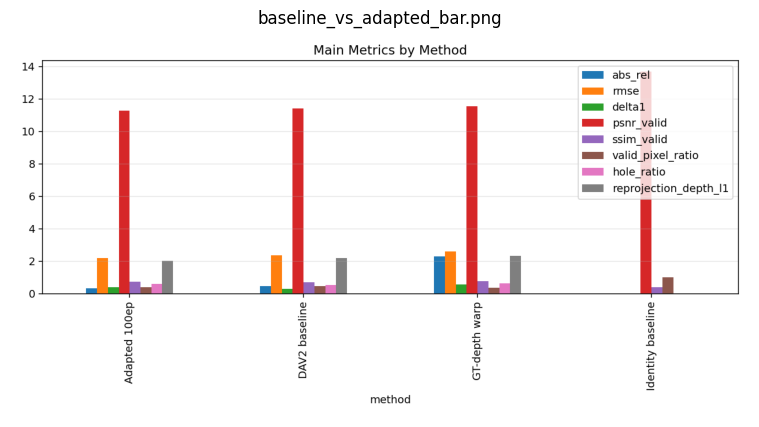

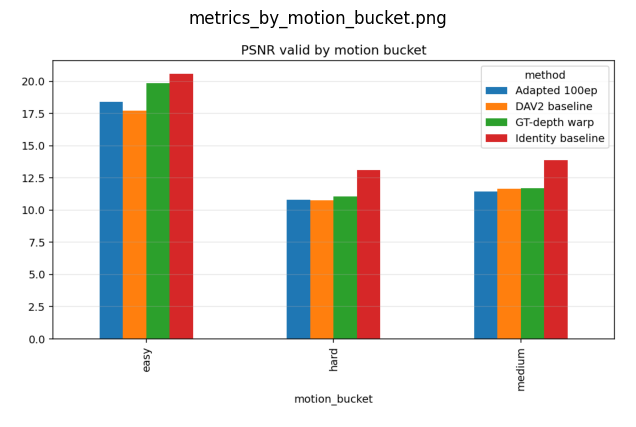

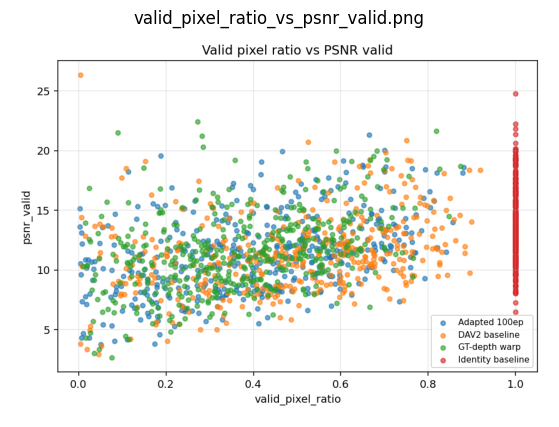

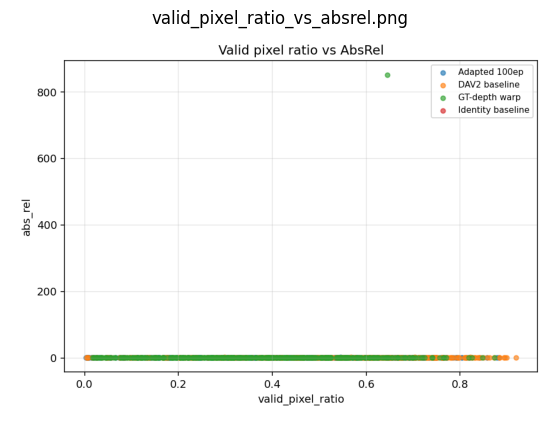

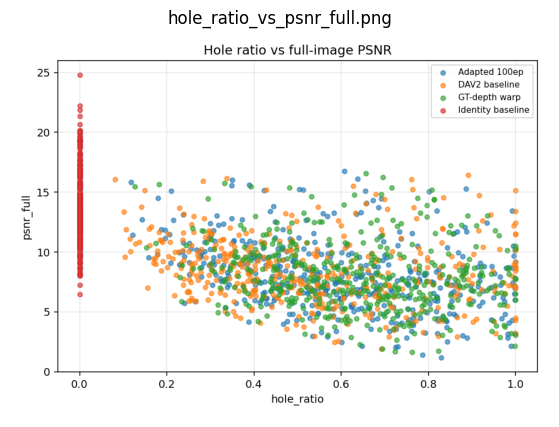

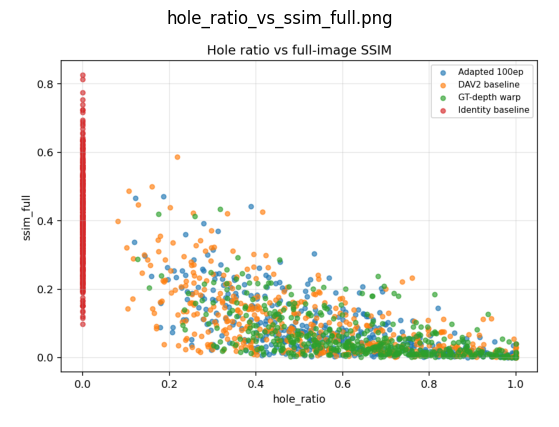

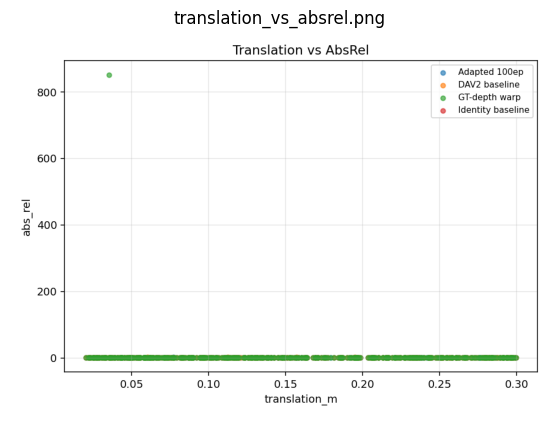

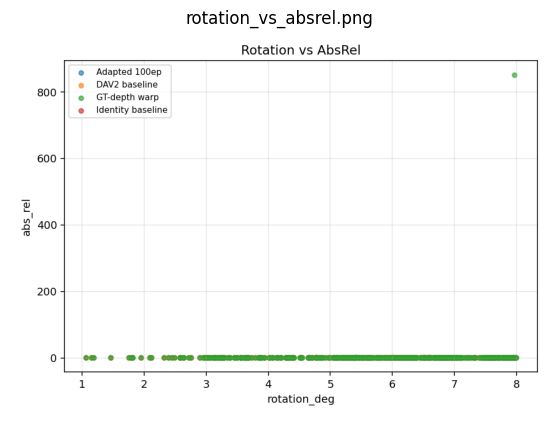

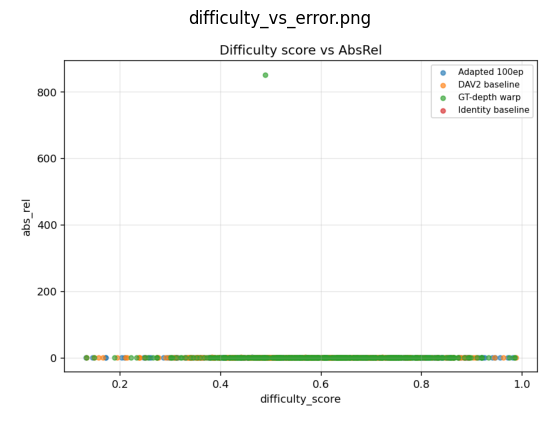

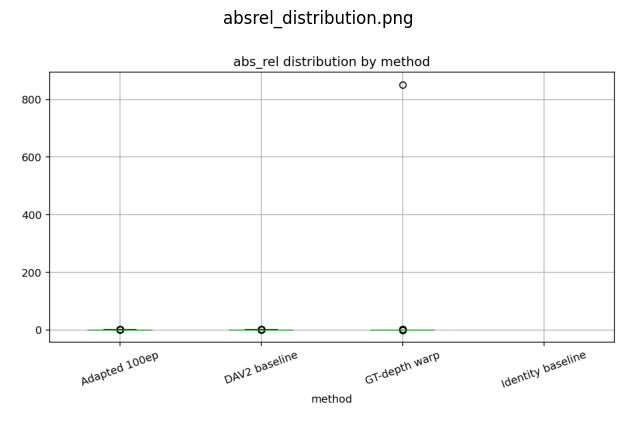

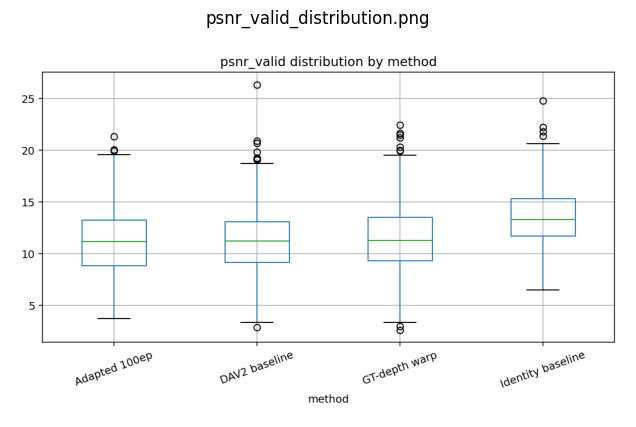

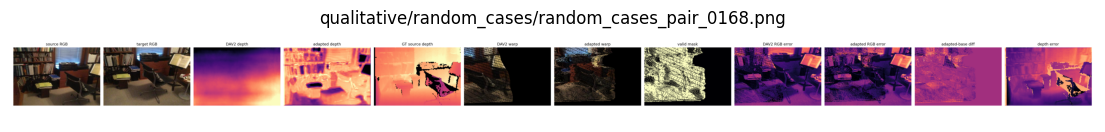

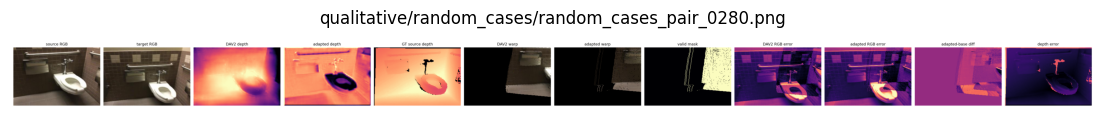

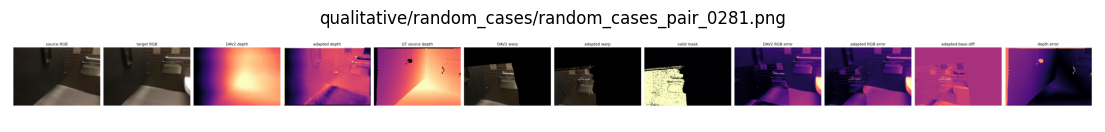

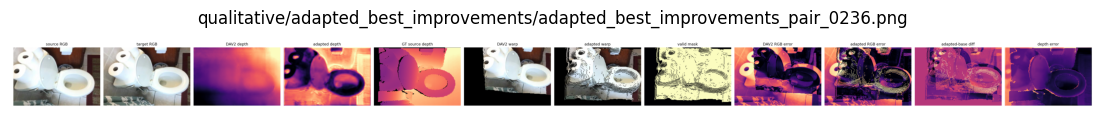

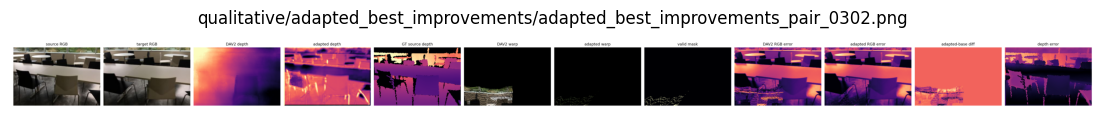

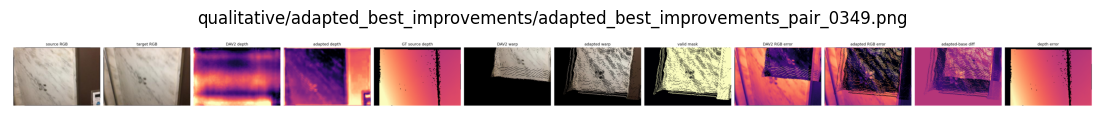

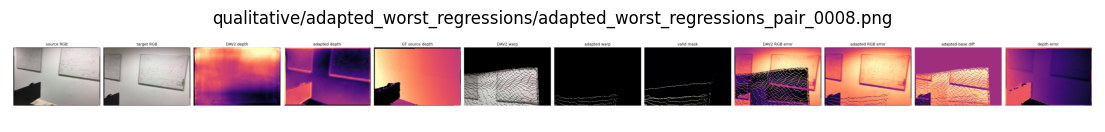

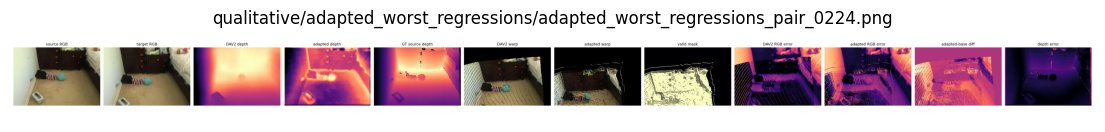

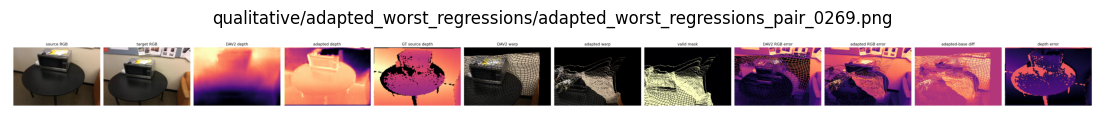

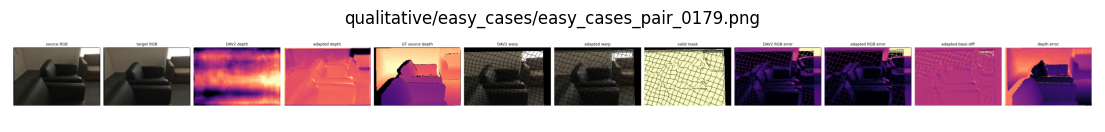

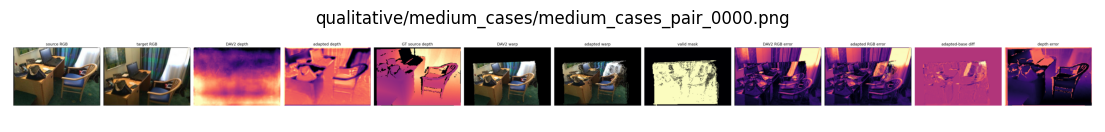

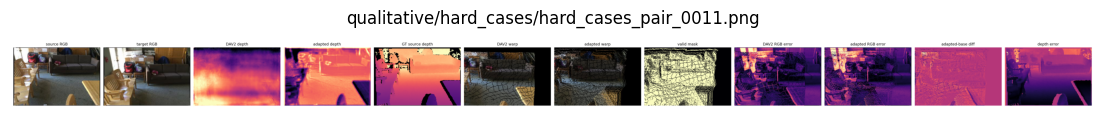

In [20]:

main_table = AGG.get("by_method", pd.DataFrame())
paired_table = AGG.get("adapted_vs_baseline_paired", pd.DataFrame())
motion_table = AGG.get("by_motion_bucket", pd.DataFrame())
depth_scale_table = AGG.get("depth_scale_diagnostics", pd.DataFrame())
runtime_table = AGG.get("runtime_memory_summary", pd.DataFrame())
skip_summary = METRICS_DF.groupby(["method", "skipped", "skip_reason"]).size().reset_index(name="count") if not METRICS_DF.empty else pd.DataFrame()

print("Output zip:", ZIP_PATH)
print("Pair errors:", PAIR_ERRORS_PATH)
print("Report:", REPORT_PATH)

print("\nMain comparison table")
display(main_table)
print("\nBaseline vs adapted paired comparison")
display(paired_table)
print("\nMotion bucket results")
display(motion_table)
print("\nDepth scale diagnostics")
display(depth_scale_table)
print("\nRuntime/memory summary")
display(runtime_table)
print("\nSkipped/error summary")
display(skip_summary)

print("\n" + final_interpretation(AGG))

important_plot_names = [
    "baseline_vs_adapted_bar.png",
    "metrics_by_motion_bucket.png",
    "valid_pixel_ratio_vs_psnr_valid.png",
    "valid_pixel_ratio_vs_absrel.png",
    "hole_ratio_vs_psnr_full.png",
    "hole_ratio_vs_ssim_full.png",
    "translation_vs_absrel.png",
    "rotation_vs_absrel.png",
    "difficulty_vs_error.png",
    "absrel_distribution.png",
    "psnr_valid_distribution.png",
]
for name in important_plot_names:
    path = OUTPUT_ROOT / "plots" / name
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(10, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(name)
        plt.show()

show_folders = [
    ("random_cases", 3),
    ("adapted_best_improvements", 3),
    ("adapted_worst_regressions", 3),
    ("easy_cases", 1),
    ("medium_cases", 1),
    ("hard_cases", 1),
]
for folder, limit in show_folders:
    paths = sorted((OUTPUT_ROOT / "qualitative" / folder).glob("*.png"))[:limit]
    for path in paths:
        img = plt.imread(path)
        plt.figure(figsize=(14, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(path.relative_to(OUTPUT_ROOT)))
        plt.show()


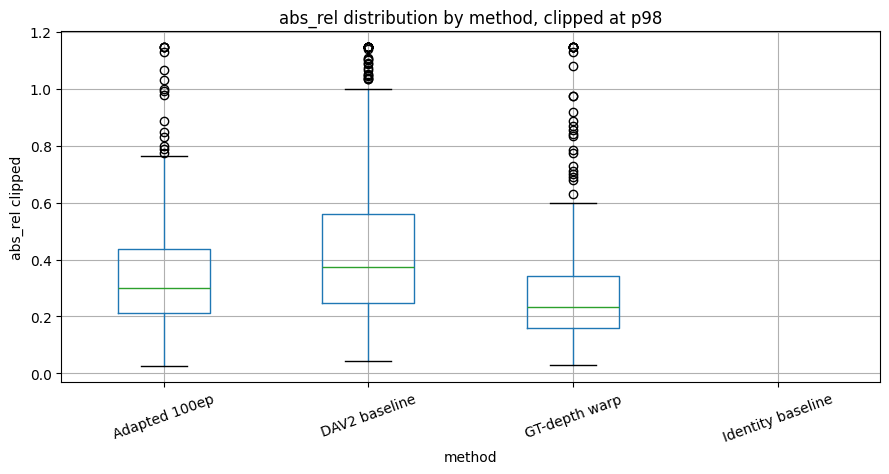

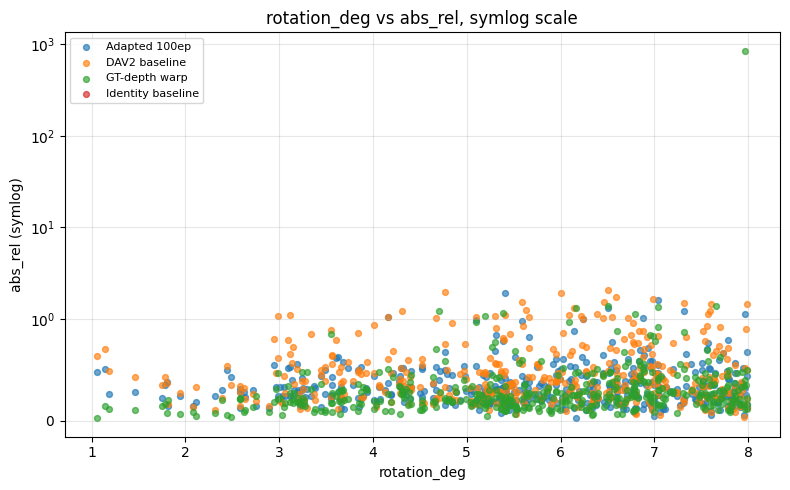

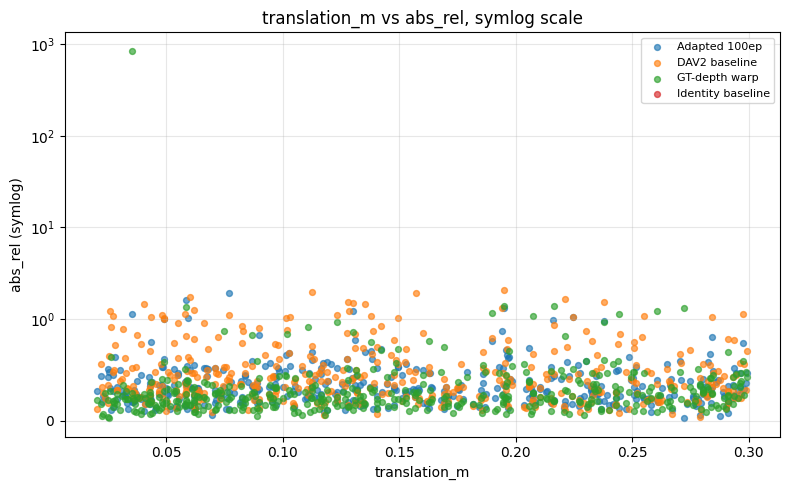

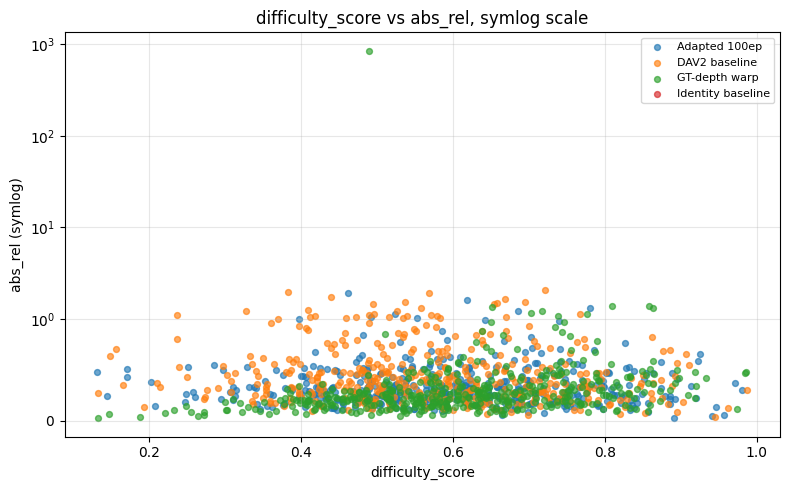

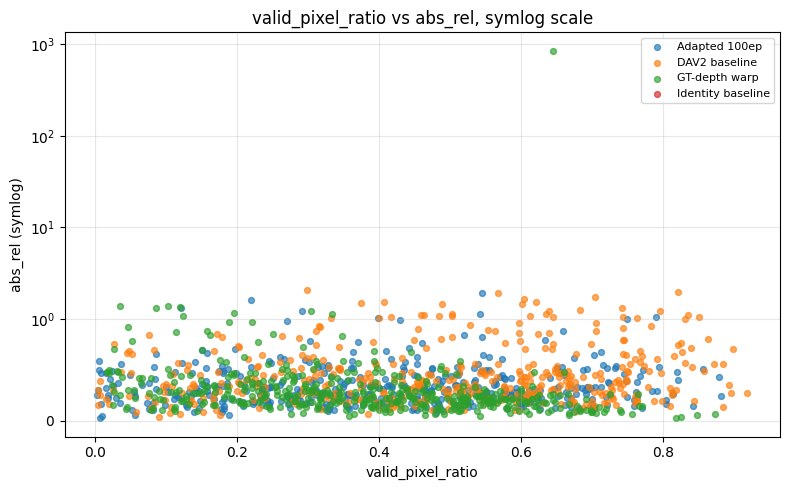

PosixPath('/kaggle/working/EagleVision/outputs/eval_suite_phase1/plots/valid_pixel_ratio_vs_absrel_symlog.png')

In [21]:
plot_df = METRICS_DF[METRICS_DF["skipped"] == False].copy()

PLOT_DIR = OUTPUT_ROOT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_clipped_boxplot(df, metric, filename, clip_q=0.98):
    d = df.copy()
    upper = d[metric].quantile(clip_q)
    d[f"{metric}_clipped"] = d[metric].clip(upper=upper)

    fig, ax = plt.subplots(figsize=(9, 5))
    d.boxplot(column=f"{metric}_clipped", by="method", ax=ax, rot=20)
    ax.set_title(f"{metric} distribution by method, clipped at p{int(clip_q*100)}")
    ax.set_ylabel(f"{metric} clipped")
    fig.suptitle("")
    fig.tight_layout()

    out = PLOT_DIR / filename
    fig.savefig(out, dpi=160)
    plt.show()
    return out

def save_log_scatter(df, x, y, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for method, g in df.groupby("method"):
        ax.scatter(g[x], g[y], s=18, alpha=0.65, label=method)

    ax.set_yscale("symlog", linthresh=1.0)
    ax.set_xlabel(x)
    ax.set_ylabel(f"{y} (symlog)")
    ax.set_title(f"{x} vs {y}, symlog scale")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()

    out = PLOT_DIR / filename
    fig.savefig(out, dpi=160)
    plt.show()
    return out

save_clipped_boxplot(plot_df, "abs_rel", "absrel_distribution_clipped_p98.png")
save_log_scatter(plot_df, "rotation_deg", "abs_rel", "rotation_vs_absrel_symlog.png")
save_log_scatter(plot_df, "translation_m", "abs_rel", "translation_vs_absrel_symlog.png")
save_log_scatter(plot_df, "difficulty_score", "abs_rel", "difficulty_vs_absrel_symlog.png")
save_log_scatter(plot_df, "valid_pixel_ratio", "abs_rel", "valid_pixel_ratio_vs_absrel_symlog.png")